# py2dataiku Master Class: Extensibility, Scenarios, MLOps & Pipelines

This notebook covers the advanced extension points and operational features of py2dataiku:

1. **Plugin Registry** -- Instance-based and global registration, hooks, and the Plugin base class
2. **Scenarios** -- Triggers, steps, reporters, and automation
3. **Metrics & Data Quality** -- Metric types, checks, and quality rules
4. **MLOps** -- API endpoints, model versioning, and drift detection
5. **Exception Handling** -- The full Py2DataikuError hierarchy
6. **Advanced Enums** -- All aggregation, window, join, and processor mode enums
7. **Real-World Pipelines** -- End-to-end ETL, ML feature engineering, data quality
8. **Grand Finale** -- Multi-zone flow with scenarios, metrics, MLOps, and visualization

---
## 1. Plugin Registry

The `PluginRegistry` allows you to extend py2dataiku with custom recipe mappings, processor mappings, and method handlers. It supports both instance-based isolation and a global default.

In [1]:
from py2dataiku.plugins.registry import (
    PluginRegistry,
    plugin_hook,
    register_recipe_handler,
    register_processor_handler,
    register_pandas_mapping,
    Plugin,
    PluginContext,
)
from py2dataiku.models.dataiku_recipe import RecipeType
from py2dataiku.models.prepare_step import ProcessorType

# Create an isolated, instance-based registry
registry = PluginRegistry()

# Add a custom recipe mapping: map a pandas method name to a Dataiku recipe type
registry.add_recipe_mapping("custom_aggregate", RecipeType.GROUPING)

# Add a custom processor mapping
registry.add_processor_mapping("custom_clean", ProcessorType.FILL_EMPTY_WITH_VALUE)

# Look up the registered mappings
print("Recipe mapping:", registry.find_recipe_mapping("custom_aggregate"))
print("Processor mapping:", registry.find_processor_mapping("custom_clean"))
print("Missing mapping:", registry.find_recipe_mapping("nonexistent"))

Recipe mapping: RecipeType.GROUPING
Processor mapping: ProcessorType.FILL_EMPTY_WITH_VALUE
Missing mapping: None


In [2]:
# Add method handlers -- custom callables that process specific pandas methods
def my_custom_handler(node, context):
    """A custom handler for a hypothetical pandas method."""
    return {"handled_by": "my_custom_handler", "node": str(node)}

registry.add_method_handler("my_custom_method", my_custom_handler)
print("Handler found:", registry.find_method_handler("my_custom_method") is not None)

# Add recipe and processor handlers
def custom_join_handler(transformation):
    return {"recipe": "custom_join", "type": "JOIN"}

def custom_fill_handler(step):
    return {"processor": "custom_fill", "type": "FILL_EMPTY"}

registry.add_recipe_handler(RecipeType.JOIN, custom_join_handler)
registry.add_processor_handler(ProcessorType.FILL_EMPTY_WITH_VALUE, custom_fill_handler)

print("Recipe handler:", registry.find_recipe_handler(RecipeType.JOIN) is not None)
print("Processor handler:", registry.find_processor_handler(ProcessorType.FILL_EMPTY_WITH_VALUE) is not None)

Handler found: True
Recipe handler: True
Processor handler: True


In [3]:
# Register a plugin with metadata
registry.add_plugin(
    name="my_analytics_plugin",
    version="2.1.0",
    description="Custom analytics transformations for our data team",
    author="Data Engineering",
)
print("Plugins:", registry._plugins)

Plugins: {'my_analytics_plugin': {'version': '2.1.0', 'description': 'Custom analytics transformations for our data team', 'author': 'Data Engineering'}}


In [4]:
# Copy a registry -- creates an independent clone
registry_copy = registry.copy()

# Modifications to the copy do not affect the original
registry_copy.add_recipe_mapping("only_in_copy", RecipeType.PIVOT)
print("Original has 'only_in_copy':", registry.find_recipe_mapping("only_in_copy") is not None)
print("Copy has 'only_in_copy':", registry_copy.find_recipe_mapping("only_in_copy") is not None)

# Remove mappings and handlers
removed = registry.remove_recipe_mapping("custom_aggregate")
print(f"Removed 'custom_aggregate': {removed}")
print("After removal:", registry.find_recipe_mapping("custom_aggregate"))

# Clear everything
registry.clear_all()
print("After clear_all, plugins:", registry._plugins)

Original has 'only_in_copy': False
Copy has 'only_in_copy': True
Removed 'custom_aggregate': True
After removal: None
After clear_all, plugins: {}


### 1.1 Global (Classmethod) API

The classmethod API provides backward compatibility. It delegates to a lazily-created default instance.

In [5]:
# Global API: class-level methods that use a shared default instance
# First clear any previous state
PluginRegistry.clear()

# Register via global classmethods
PluginRegistry.register_recipe_mapping("global_merge", RecipeType.JOIN)
PluginRegistry.register_processor_mapping("global_clean", ProcessorType.STRING_TRANSFORMER)
PluginRegistry.register_method_handler("global_method", lambda n, c: None)
PluginRegistry.register_plugin("global_plugin", version="1.0.0", description="A global plugin")

# Query via global classmethods
print("Global recipe mappings:", PluginRegistry.list_recipe_mappings())
print("Global processor mappings:", PluginRegistry.list_processor_mappings())
print("Global plugins:", PluginRegistry.list_plugins())

# Clean up
PluginRegistry.unregister_recipe_mapping("global_merge")
PluginRegistry.unregister_processor_mapping("global_clean")
PluginRegistry.unregister_method_handler("global_method")
PluginRegistry.clear()

Global recipe mappings: {'global_merge': <RecipeType.JOIN: 'join'>}
Global processor mappings: {'global_clean': <ProcessorType.STRING_TRANSFORMER: 'StringTransformer'>}
Global plugins: {'global_plugin': {'version': '1.0.0', 'description': 'A global plugin'}}


### 1.2 The `plugin_hook` Decorator

The `plugin_hook` decorator registers a function as a plugin hook on the global registry.

In [6]:
# Clear global state first
PluginRegistry.clear()

# The plugin_hook decorator registers by function name for "pandas_method" hooks
@plugin_hook("pandas_method")
def handle_special_transform(node, context):
    """Automatically registered as a method handler for 'handle_special_transform'."""
    return {"processed": True}

# Verify registration
handler = PluginRegistry.get_method_handler("handle_special_transform")
print("Handler registered:", handler is not None)
print("Handler result:", handler("test_node", {}))

PluginRegistry.clear()

Handler registered: True
Handler result: {'processed': True}


### 1.3 Decorator-Based Recipe & Processor Registration

In [7]:
# Clear global state
PluginRegistry.clear()

# register_recipe_handler decorator -- registers a function to handle a recipe type
@register_recipe_handler(RecipeType.WINDOW)
def custom_window_recipe(transformation):
    """Custom handler for Window recipes."""
    return {"custom_window": True, "transformation": str(transformation)}

# register_processor_handler decorator
@register_processor_handler(ProcessorType.BINNER)
def custom_binner_processor(step):
    """Custom handler for Binner processors."""
    return {"custom_binner": True, "step": str(step)}

# Verify
print("Window handler:", PluginRegistry.get_recipe_handler(RecipeType.WINDOW) is not None)
print("Binner handler:", PluginRegistry.get_processor_handler(ProcessorType.BINNER) is not None)

PluginRegistry.clear()

Window handler: True
Binner handler: True


### 1.4 The `register_pandas_mapping` Convenience Function

In [8]:
PluginRegistry.clear()

# Convenience function that auto-detects whether the target is a RecipeType or ProcessorType
register_pandas_mapping("custom_fill", ProcessorType.FILL_EMPTY_WITH_VALUE)
register_pandas_mapping("custom_agg", RecipeType.GROUPING)

# With an optional handler
def my_agg_handler(node, context):
    return {"aggregated": True}

register_pandas_mapping("custom_agg2", RecipeType.GROUPING, handler=my_agg_handler)

print("Processor mapping:", PluginRegistry.get_processor_mapping("custom_fill"))
print("Recipe mapping:", PluginRegistry.get_recipe_mapping("custom_agg"))
print("Handler for custom_agg2:", PluginRegistry.get_method_handler("custom_agg2") is not None)

PluginRegistry.clear()

Processor mapping: ProcessorType.FILL_EMPTY_WITH_VALUE
Recipe mapping: RecipeType.GROUPING
Handler for custom_agg2: True


### 1.5 The `Plugin` Base Class

For organizing multiple related registrations, subclass `Plugin`.

In [9]:
# Create a custom plugin by subclassing Plugin
class TimeSeriesPlugin(Plugin):
    name = "timeseries_plugin"
    version = "1.0.0"
    description = "Time series analysis extensions"

    def register(self):
        # Register mappings within the plugin
        self.add_recipe_mapping("resample", RecipeType.WINDOW)
        self.add_processor_mapping("interpolate", ProcessorType.FILL_EMPTY_WITH_COMPUTED_VALUE)
        self.add_method_handler("seasonal_decompose", self.handle_decompose)

    def handle_decompose(self, node, context):
        return {"decompose": True, "components": ["trend", "seasonal", "residual"]}

# Activate on a fresh registry
ts_registry = PluginRegistry()
ts_plugin = TimeSeriesPlugin(registry=ts_registry)
ts_plugin.activate()

print("Plugin registered:", ts_registry._plugins)
print("Recipe mapping:", ts_registry.find_recipe_mapping("resample"))
print("Processor mapping:", ts_registry.find_processor_mapping("interpolate"))
print("Handler result:", ts_registry.find_method_handler("seasonal_decompose")(None, None))

# Deactivate removes all the plugin's registrations
ts_plugin.deactivate()
print("\nAfter deactivation:")
print("Recipe mapping:", ts_registry.find_recipe_mapping("resample"))

Plugin registered: {'timeseries_plugin': {'version': '1.0.0', 'description': 'Time series analysis extensions'}}
Recipe mapping: RecipeType.WINDOW
Processor mapping: ProcessorType.FILL_EMPTY_WITH_COMPUTED_VALUE
Handler result: {'decompose': True, 'components': ['trend', 'seasonal', 'residual']}

After deactivation:
Recipe mapping: None


### 1.6 PluginContext

`PluginContext` provides state information to plugin handlers during code analysis.

In [10]:
# PluginContext carries analysis state to handlers
ctx = PluginContext(
    source_code="df = pd.read_csv('sales.csv')\ndf = df.dropna()",
    current_line=2,
    variables={"df": "DataFrame", "threshold": 100},
    dataframes={"df": "sales_data"},
)

print("Source code:", ctx.source_code[:40], "...")
print("Current line:", ctx.current_line)
print("Variable 'df':", ctx.get_variable("df"))
print("Variable 'threshold':", ctx.get_variable("threshold"))
print("Dataframe source:", ctx.get_dataframe_source("df"))
print("Missing variable:", ctx.get_variable("missing"))

Source code: df = pd.read_csv('sales.csv')
df = df.dr ...
Current line: 2
Variable 'df': DataFrame
Variable 'threshold': 100
Dataframe source: sales_data
Missing variable: None


---
## 2. Scenarios

Dataiku scenarios automate flow execution with triggers, steps, and reporters.

In [11]:
from py2dataiku.models.dataiku_scenario import (
    DataikuScenario,
    ScenarioTrigger,
    ScenarioStep,
    ScenarioReporter,
    TriggerType,
    StepType,
    ReporterType,
)

# Enumerate all trigger, step, and reporter types
print("Trigger types:", [t.value for t in TriggerType])
print("Step types:", [s.value for s in StepType])
print("Reporter types:", [r.value for r in ReporterType])

Trigger types: ['time_based', 'dataset_change', 'sql_query', 'python']
Step types: ['build_dataset', 'train_model', 'run_checks', 'execute_sql', 'execute_python', 'send_message']
Reporter types: ['email', 'slack', 'webhook']


In [12]:
# Create triggers using factory methods
nightly_trigger = ScenarioTrigger.time_based(
    name="nightly_run",
    cron="0 2 * * *",  # 2 AM daily
    timezone="US/Eastern",
)
print("Time-based trigger:", nightly_trigger.to_dict())

data_trigger = ScenarioTrigger.dataset_change(
    name="on_new_data",
    dataset="raw_transactions",
)
print("Dataset change trigger:", data_trigger.to_dict())

# Manual trigger construction for other types
sql_trigger = ScenarioTrigger(
    name="check_new_records",
    trigger_type=TriggerType.SQL_QUERY,
    params={"query": "SELECT COUNT(*) > 0 FROM staging.new_data", "connection": "postgres"},
)
print("SQL trigger:", sql_trigger.to_dict())

Time-based trigger: {'name': 'nightly_run', 'type': 'time_based', 'params': {'cron': '0 2 * * *', 'timezone': 'US/Eastern'}, 'active': True}
Dataset change trigger: {'name': 'on_new_data', 'type': 'dataset_change', 'params': {'dataset': 'raw_transactions'}, 'active': True}
SQL trigger: {'name': 'check_new_records', 'type': 'sql_query', 'params': {'query': 'SELECT COUNT(*) > 0 FROM staging.new_data', 'connection': 'postgres'}, 'active': True}


In [13]:
# Create steps using factory methods
build_step = ScenarioStep.build("Build clean data", dataset="clean_transactions")
train_step = ScenarioStep.train("Retrain model", model_id="fraud_detector_v3")
check_step = ScenarioStep.run_checks("Validate output", dataset="predictions")

python_step = ScenarioStep.execute_python(
    "Custom validation",
    code="import dataiku\nds = dataiku.Dataset('predictions')\nassert ds.get_dataframe().shape[0] > 0",
)

notify_step = ScenarioStep.send_message(
    "Notify team",
    channel="#data-alerts",
    message="Pipeline completed successfully",
)

for step in [build_step, train_step, check_step, python_step, notify_step]:
    print(f"  {step.name}: {step.step_type.value}")

  Build clean data: build_dataset
  Retrain model: train_model
  Validate output: run_checks
  Custom validation: execute_python
  Notify team: send_message


In [14]:
# Create reporters using factory methods
email_reporter = ScenarioReporter.email(
    name="Team email",
    recipients=["data-team@company.com", "ops@company.com"],
    subject="Pipeline Report: Fraud Detection",
)

slack_reporter = ScenarioReporter.slack(
    name="Slack alerts",
    channel="#ml-pipelines",
    webhook_url="https://example.com/slack-webhook-placeholder",
)

webhook_reporter = ScenarioReporter.webhook(
    name="PagerDuty",
    url="https://events.pagerduty.com/v2/enqueue",
)
# Only trigger PagerDuty on failure
webhook_reporter.on_success = False

for r in [email_reporter, slack_reporter, webhook_reporter]:
    print(f"  {r.name}: type={r.reporter_type.value}, on_success={r.on_success}, on_failure={r.on_failure}")

  Team email: type=email, on_success=True, on_failure=True
  Slack alerts: type=slack, on_success=True, on_failure=True
  PagerDuty: type=webhook, on_success=False, on_failure=True


In [15]:
# Assemble a complete scenario
scenario = DataikuScenario(
    name="fraud_detection_pipeline",
    active=True,
    tags=["production", "ml", "fraud"],
)

# Add triggers
scenario.add_trigger(nightly_trigger)
scenario.add_trigger(data_trigger)

# Add steps in execution order
scenario.add_step(build_step)
scenario.add_step(train_step)
scenario.add_step(check_step)
scenario.add_step(python_step)
scenario.add_step(notify_step)

# Add reporters
scenario.add_reporter(email_reporter)
scenario.add_reporter(slack_reporter)
scenario.add_reporter(webhook_reporter)

print(repr(scenario))
print("\nTags:", scenario.tags)

DataikuScenario(name='fraud_detection_pipeline', triggers=2, steps=5, reporters=3)

Tags: ['production', 'ml', 'fraud']


In [16]:
# Serialization round-trip
scenario_dict = scenario.to_dict()
print("Keys in to_dict():", list(scenario_dict.keys()))
print("Number of triggers:", len(scenario_dict["triggers"]))
print("Number of steps:", len(scenario_dict["steps"]))

# Round-trip: from_dict recreates the scenario
scenario_restored = DataikuScenario.from_dict(scenario_dict)
print("\nRestored:", repr(scenario_restored))
print("Triggers match:", len(scenario_restored.triggers) == len(scenario.triggers))

# API-compatible JSON
api_json = scenario.to_json()
print("\nAPI JSON keys:", list(api_json.keys()))
print("Scenario type:", api_json["type"])

Keys in to_dict(): ['name', 'active', 'tags', 'triggers', 'steps', 'reporters']
Number of triggers: 2
Number of steps: 5

Restored: DataikuScenario(name='fraud_detection_pipeline', triggers=2, steps=5, reporters=3)
Triggers match: True

API JSON keys: ['id', 'name', 'type', 'active', 'params', 'versionTag']
Scenario type: step_based


---
## 3. Metrics & Data Quality

py2dataiku models Dataiku's metric computation, check validation, and data quality rules.

In [17]:
from py2dataiku.models.dataiku_metrics import (
    DataikuMetric,
    DataikuCheck,
    DataQualityRule,
    MetricType,
    CheckCondition,
    CheckSeverity,
)

# All metric types
print("Metric types:")
for mt in MetricType:
    print(f"  {mt.name}: {mt.value}")

print("\nCheck conditions:")
for cc in CheckCondition:
    print(f"  {cc.name}: {cc.value}")

print("\nSeverity levels:", [s.value for s in CheckSeverity])

Metric types:
  ROW_COUNT: row_count
  COLUMN_MIN: column_min
  COLUMN_MAX: column_max
  COLUMN_AVG: column_avg
  COLUMN_SUM: column_sum
  COLUMN_STDDEV: column_stddev
  COLUMN_DISTINCT: column_distinct
  COLUMN_MISSING: column_missing
  CUSTOM_SQL: custom_sql
  CUSTOM_PYTHON: custom_python

Check conditions:
  EQUALS: equals
  NOT_EQUALS: not_equals
  GREATER_THAN: greater_than
  LESS_THAN: less_than
  GREATER_OR_EQUAL: greater_or_equal
  LESS_OR_EQUAL: less_or_equal
  BETWEEN: between
  NOT_EMPTY: not_empty

Severity levels: ['WARNING', 'ERROR']


In [18]:
# Create metrics using factory methods
row_count = DataikuMetric.row_count()
price_min = DataikuMetric.column_min("price")
price_max = DataikuMetric.column_max("price")
price_avg = DataikuMetric.column_avg("price", name="avg_price")
missing_email = DataikuMetric.column_missing("email")
revenue_sql = DataikuMetric.custom_sql(
    name="total_revenue",
    query="SELECT SUM(price * quantity) FROM transactions",
)

# Manual construction for other types
distinct_metric = DataikuMetric(
    name="category_count",
    metric_type=MetricType.COLUMN_DISTINCT,
    column="category",
)

for m in [row_count, price_min, price_max, price_avg, missing_email, revenue_sql, distinct_metric]:
    print(f"  {m.name}: type={m.metric_type.value}, column={m.column}")

  row_count: type=row_count, column=None
  price_min: type=column_min, column=price
  price_max: type=column_max, column=price
  avg_price: type=column_avg, column=price
  email_missing: type=column_missing, column=email
  total_revenue: type=custom_sql, column=None
  category_count: type=column_distinct, column=category


In [19]:
# Create checks using factory methods
not_empty_check = DataikuCheck.not_empty(
    name="has_data",
    metric_name="row_count",
)

price_range_check = DataikuCheck.between(
    name="price_in_range",
    metric_name="avg_price",
    min_value=10.0,
    max_value=10000.0,
    severity=CheckSeverity.ERROR,
)

# Manual check with specific condition
missing_check = DataikuCheck(
    name="low_missing_emails",
    metric_name="email_missing",
    condition=CheckCondition.LESS_THAN,
    value=100,
    severity=CheckSeverity.WARNING,
)

for c in [not_empty_check, price_range_check, missing_check]:
    d = c.to_dict()
    print(f"  {c.name}: condition={c.condition.value}, severity={c.severity.value}")

# Round-trip
check_dict = price_range_check.to_dict()
check_restored = DataikuCheck.from_dict(check_dict)
print("\nRound-trip check:", check_restored.name, check_restored.min_value, check_restored.max_value)

  has_data: condition=not_empty, severity=ERROR
  price_in_range: condition=between, severity=ERROR
  low_missing_emails: condition=less_than, severity=WARNING

Round-trip check: price_in_range 10.0 10000.0


In [20]:
# Data Quality Rules -- column-level validation
rules = [
    DataQualityRule.not_null("customer_id"),
    DataQualityRule.unique("order_id"),
    DataQualityRule.in_range("quantity", min_value=1, max_value=10000),
    DataQualityRule.regex_match("email", r"^[\w.+-]+@[\w-]+\.[\w.]+$"),
    DataQualityRule.in_set("status", ["pending", "shipped", "delivered", "returned"]),
]

for rule in rules:
    d = rule.to_dict()
    print(f"  {rule.name}: column={rule.column}, type={rule.rule_type}, severity={rule.severity.value}")

# Round-trip for quality rules
rule_dict = rules[2].to_dict()
rule_restored = DataQualityRule.from_dict(rule_dict)
print(f"\nRestored rule: {rule_restored.name}, params={rule_restored.params}")

  customer_id_not_null: column=customer_id, type=not_null, severity=ERROR
  order_id_unique: column=order_id, type=unique, severity=ERROR
  quantity_in_range: column=quantity, type=in_range, severity=ERROR
  email_regex: column=email, type=regex_match, severity=ERROR
  status_in_set: column=status, type=in_set, severity=ERROR

Restored rule: quantity_in_range, params={'min': 1, 'max': 10000}


---
## 4. MLOps

py2dataiku models Dataiku's MLOps features: API endpoint deployment, model versioning, and drift detection.

In [21]:
from py2dataiku.models.dataiku_mlops import (
    APIEndpoint,
    ModelVersion,
    DriftConfig,
    EndpointType,
    ModelFramework,
    DriftMetricType,
)

# Enumerate all MLOps enums
print("Endpoint types:", [e.value for e in EndpointType])
print("Model frameworks:", [f.value for f in ModelFramework])
print("Drift metric types:", [d.value for d in DriftMetricType])

Endpoint types: ['rest', 'batch']
Model frameworks: ['scikit_learn', 'xgboost', 'lightgbm', 'tensorflow', 'pytorch', 'custom']
Drift metric types: ['psi', 'ks', 'chi_squared', 'wasserstein']


In [22]:
# Create an API endpoint for model serving
endpoint = APIEndpoint(
    name="fraud_scoring_api",
    model_name="fraud_detector_v3",
    endpoint_type=EndpointType.REST,
    url_path="/api/v1/fraud/score",
    input_schema={
        "transaction_id": "string",
        "amount": "float",
        "merchant_category": "string",
        "customer_age": "int",
        "is_international": "boolean",
    },
    output_schema={
        "fraud_probability": "float",
        "risk_level": "string",
        "explanation": "string",
    },
    auth_required=True,
    rate_limit=1000,
)

# A batch endpoint for bulk scoring
batch_endpoint = APIEndpoint(
    name="batch_scoring",
    model_name="fraud_detector_v3",
    endpoint_type=EndpointType.BATCH,
    auth_required=True,
)

print("REST endpoint:")
for k, v in endpoint.to_dict().items():
    print(f"  {k}: {v}")

# Round-trip
ep_restored = APIEndpoint.from_dict(endpoint.to_dict())
print(f"\nRestored: {ep_restored.name}, rate_limit={ep_restored.rate_limit}")

REST endpoint:
  name: fraud_scoring_api
  modelName: fraud_detector_v3
  type: rest
  authRequired: True
  urlPath: /api/v1/fraud/score
  inputSchema: {'transaction_id': 'string', 'amount': 'float', 'merchant_category': 'string', 'customer_age': 'int', 'is_international': 'boolean'}
  outputSchema: {'fraud_probability': 'float', 'risk_level': 'string', 'explanation': 'string'}
  rateLimit: 1000

Restored: fraud_scoring_api, rate_limit=1000


In [23]:
# Track model versions across the ML lifecycle
v1 = ModelVersion(
    version_id="v1.0",
    model_name="fraud_detector",
    framework=ModelFramework.SCIKIT_LEARN,
    algorithm="RandomForest",
    metrics={"accuracy": 0.92, "f1": 0.87, "auc_roc": 0.95},
    features=["amount", "merchant_category", "customer_age", "is_international"],
    target="is_fraud",
    active=False,
    tags=["baseline"],
)

v2 = ModelVersion(
    version_id="v2.0",
    model_name="fraud_detector",
    framework=ModelFramework.XGBOOST,
    algorithm="XGBClassifier",
    metrics={"accuracy": 0.96, "f1": 0.93, "auc_roc": 0.98},
    features=["amount", "merchant_category", "customer_age", "is_international", "hour_of_day", "day_of_week"],
    target="is_fraud",
    active=True,
    tags=["production", "champion"],
)

v3 = ModelVersion(
    version_id="v3.0-beta",
    model_name="fraud_detector",
    framework=ModelFramework.PYTORCH,
    algorithm="TransformerEncoder",
    metrics={"accuracy": 0.97, "f1": 0.95, "auc_roc": 0.99},
    features=["amount", "merchant_category", "customer_age", "is_international",
              "hour_of_day", "day_of_week", "transaction_velocity", "geo_distance"],
    target="is_fraud",
    active=False,
    tags=["challenger", "beta"],
)

for v in [v1, v2, v3]:
    print(f"  {v.version_id}: {v.framework.value}/{v.algorithm}, "
          f"AUC={v.metrics.get('auc_roc', 'N/A')}, active={v.active}, tags={v.tags}")

  v1.0: scikit_learn/RandomForest, AUC=0.95, active=False, tags=['baseline']
  v2.0: xgboost/XGBClassifier, AUC=0.98, active=True, tags=['production', 'champion']
  v3.0-beta: pytorch/TransformerEncoder, AUC=0.99, active=False, tags=['challenger', 'beta']


In [24]:
# Configure drift detection for each metric type
drift_psi = DriftConfig(
    enabled=True,
    metric=DriftMetricType.PSI,
    threshold=0.2,
    columns=["amount", "merchant_category", "customer_age"],
    check_frequency="daily",
)

drift_ks = DriftConfig(
    enabled=True,
    metric=DriftMetricType.KS,
    threshold=0.05,
    columns=["amount"],
    check_frequency="hourly",
)

drift_wasserstein = DriftConfig(
    enabled=True,
    metric=DriftMetricType.WASSERSTEIN,
    threshold=0.1,
    columns=["amount", "customer_age"],
    check_frequency="weekly",
)

drift_chi2 = DriftConfig(
    enabled=True,
    metric=DriftMetricType.CHI_SQUARED,
    threshold=0.01,
    columns=["merchant_category", "is_international"],
    check_frequency="daily",
)

for dc in [drift_psi, drift_ks, drift_wasserstein, drift_chi2]:
    d = dc.to_dict()
    print(f"  {dc.metric.value}: threshold={dc.threshold}, freq={dc.check_frequency}, columns={dc.columns}")

# Round-trip
dc_restored = DriftConfig.from_dict(drift_psi.to_dict())
print(f"\nRestored drift config: metric={dc_restored.metric.value}, threshold={dc_restored.threshold}")

  psi: threshold=0.2, freq=daily, columns=['amount', 'merchant_category', 'customer_age']
  ks: threshold=0.05, freq=hourly, columns=['amount']
  wasserstein: threshold=0.1, freq=weekly, columns=['amount', 'customer_age']
  chi_squared: threshold=0.01, freq=daily, columns=['merchant_category', 'is_international']

Restored drift config: metric=psi, threshold=0.2


---
## 5. Exception Handling

The py2dataiku exception hierarchy allows fine-grained error handling.

In [25]:
from py2dataiku.exceptions import (
    Py2DataikuError,
    ConversionError,
    InvalidPythonCodeError,
    ProviderError,
    LLMResponseParseError,
    ValidationError,
    ExportError,
    ConfigurationError,
)

# Display the hierarchy
print("Exception hierarchy:")
print("  Py2DataikuError")
print("  +-- ConversionError")
print("  |   +-- InvalidPythonCodeError")
print("  +-- ProviderError")
print("  |   +-- LLMResponseParseError")
print("  +-- ValidationError")
print("  +-- ExportError")
print("  +-- ConfigurationError")

# Verify inheritance
print("\nInheritance checks:")
print(f"  InvalidPythonCodeError -> ConversionError: {issubclass(InvalidPythonCodeError, ConversionError)}")
print(f"  InvalidPythonCodeError -> Py2DataikuError: {issubclass(InvalidPythonCodeError, Py2DataikuError)}")
print(f"  LLMResponseParseError -> ProviderError: {issubclass(LLMResponseParseError, ProviderError)}")
print(f"  LLMResponseParseError -> Py2DataikuError: {issubclass(LLMResponseParseError, Py2DataikuError)}")

Exception hierarchy:
  Py2DataikuError
  +-- ConversionError
  |   +-- InvalidPythonCodeError
  +-- ProviderError
  |   +-- LLMResponseParseError
  +-- ValidationError
  +-- ExportError
  +-- ConfigurationError

Inheritance checks:
  InvalidPythonCodeError -> ConversionError: True
  InvalidPythonCodeError -> Py2DataikuError: True
  LLMResponseParseError -> ProviderError: True
  LLMResponseParseError -> Py2DataikuError: True


In [26]:
# Demonstrate catching specific exceptions
import py2dataiku

# InvalidPythonCodeError when code cannot be parsed
try:
    flow = py2dataiku.convert("this is not valid python @@##$$")
except InvalidPythonCodeError as e:
    print(f"Caught InvalidPythonCodeError: {e}")
except ConversionError as e:
    print(f"Caught ConversionError: {e}")
except Py2DataikuError as e:
    print(f"Caught base Py2DataikuError: {e}")

# Demonstrate raising and catching each exception type
for exc_class, msg in [
    (ValidationError, "Recipe 'join_1' has no input datasets"),
    (ExportError, "Cannot write to /readonly/path"),
    (ConfigurationError, "Invalid provider: 'nonexistent'"),
]:
    try:
        raise exc_class(msg)
    except Py2DataikuError as e:
        print(f"  {type(e).__name__}: {e}")

Caught InvalidPythonCodeError: Invalid Python syntax at line 1: invalid syntax
  ValidationError: Recipe 'join_1' has no input datasets
  ExportError: Cannot write to /readonly/path
  ConfigurationError: Invalid provider: 'nonexistent'


---
## 6. Advanced Enums Showcase

py2dataiku provides extensive enums covering Dataiku's full range of operations.

In [27]:
from py2dataiku.models.dataiku_recipe import (
    AggregationFunction,
    JoinType,
    JoinConditionType,
    WindowFunctionType,
    SamplingMethod,
    SplitMode,
    GeoJoinOperator,
    DistanceUnit,
)
from py2dataiku.models.prepare_step import (
    StringTransformerMode,
    NumericalTransformerMode,
    FilterMatchMode,
    DateComponentType,
    BinningMode,
    NormalizationMode,
    EncodingType,
)

# AggregationFunction: 26 values across basic, statistical, percentile, and collection
print(f"AggregationFunction ({len(list(AggregationFunction))} values):")
categories = {
    "Basic": ["SUM", "AVG", "MEAN", "COUNT", "COUNTD", "MIN", "MAX", "FIRST", "LAST"],
    "Statistical": ["STD", "STDDEV", "VAR", "VARIANCE", "MEDIAN", "MODE", "NUNIQUE"],
    "Percentile": ["PERCENTILE_25", "PERCENTILE_50", "PERCENTILE_75", "PERCENTILE_90", "PERCENTILE_95", "PERCENTILE_99"],
    "Collection": ["CONCAT", "COLLECT_LIST", "COLLECT_SET"],
}
for cat, members in categories.items():
    vals = [AggregationFunction[m].value for m in members]
    print(f"  {cat}: {vals}")

AggregationFunction (25 values):
  Basic: ['SUM', 'AVG', 'MEAN', 'COUNT', 'COUNTD', 'MIN', 'MAX', 'FIRST', 'LAST']
  Statistical: ['STD', 'STDDEV', 'VAR', 'VARIANCE', 'MEDIAN', 'MODE', 'NUNIQUE']
  Percentile: ['PERCENTILE_25', 'PERCENTILE_50', 'PERCENTILE_75', 'PERCENTILE_90', 'PERCENTILE_95', 'PERCENTILE_99']
  Collection: ['CONCAT', 'COLLECT_LIST', 'COLLECT_SET']


In [28]:
# JoinType: 8 values
print(f"JoinType ({len(list(JoinType))} values):")
for jt in JoinType:
    print(f"  {jt.name} = {jt.value}")

# JoinConditionType: 10 values for advanced join conditions
print(f"\nJoinConditionType ({len(list(JoinConditionType))} values):")
for jc in JoinConditionType:
    print(f"  {jc.name} = {jc.value}")

JoinType (8 values):
  INNER = INNER
  LEFT = LEFT
  RIGHT = RIGHT
  OUTER = OUTER
  CROSS = CROSS
  LEFT_ANTI = LEFT_ANTI
  RIGHT_ANTI = RIGHT_ANTI
  ADVANCED = ADVANCED

JoinConditionType (11 values):
  EQ = EQ
  LTE = LTE
  LT = LT
  GTE = GTE
  GT = GT
  NE = NE
  WITHIN_RANGE = WITHIN_RANGE
  K_NEAREST = K_NEAREST
  K_NEAREST_INFERIOR = K_NEAREST_INFERIOR
  CONTAINS = CONTAINS
  STARTS_WITH = STARTS_WITH


In [29]:
# WindowFunctionType: 23 values across ranking, offset, running, and moving
print(f"WindowFunctionType ({len(list(WindowFunctionType))} values):")
window_categories = {
    "Ranking": ["ROW_NUMBER", "RANK", "DENSE_RANK", "NTILE", "PERCENT_RANK", "CUME_DIST"],
    "Offset": ["LAG", "LEAD", "LAG_DIFF", "LEAD_DIFF", "FIRST_VALUE", "LAST_VALUE", "NTH_VALUE"],
    "Running": ["RUNNING_SUM", "RUNNING_AVG", "RUNNING_MIN", "RUNNING_MAX", "RUNNING_COUNT"],
    "Moving": ["MOVING_AVG", "MOVING_SUM", "MOVING_MIN", "MOVING_MAX", "MOVING_STDDEV"],
}
for cat, members in window_categories.items():
    vals = [WindowFunctionType[m].value for m in members]
    print(f"  {cat}: {vals}")

WindowFunctionType (23 values):
  Ranking: ['ROW_NUMBER', 'RANK', 'DENSE_RANK', 'NTILE', 'PERCENT_RANK', 'CUME_DIST']
  Offset: ['LAG', 'LEAD', 'LAG_DIFF', 'LEAD_DIFF', 'FIRST_VALUE', 'LAST_VALUE', 'NTH_VALUE']
  Running: ['RUNNING_SUM', 'RUNNING_AVG', 'RUNNING_MIN', 'RUNNING_MAX', 'RUNNING_COUNT']
  Moving: ['MOVING_AVG', 'MOVING_SUM', 'MOVING_MIN', 'MOVING_MAX', 'MOVING_STDDEV']


In [30]:
# StringTransformerMode: 22 values
print(f"StringTransformerMode ({len(list(StringTransformerMode))} values):")
str_categories = {
    "Case": [m for m in StringTransformerMode if m.name in ["UPPERCASE", "LOWERCASE", "TITLECASE", "CAPITALIZE", "SWAPCASE"]],
    "Whitespace": [m for m in StringTransformerMode if "TRIM" in m.name or "WHITESPACE" in m.name],
    "Cleaning": [m for m in StringTransformerMode if "REMOVE" in m.name or "KEEP" in m.name or m.name in ["ASCII_TRANSLITERATE"]],
    "Padding": [m for m in StringTransformerMode if "PAD" in m.name],
    "Other": [m for m in StringTransformerMode if m.name in ["REVERSE", "QUOTE", "UNQUOTE"]],
}
for cat, members in str_categories.items():
    print(f"  {cat}: {[m.value for m in members]}")

StringTransformerMode (25 values):
  Case: ['TO_UPPER', 'TO_LOWER', 'TITLECASE', 'CAPITALIZE', 'SWAPCASE']
  Whitespace: ['TRIM', 'TRIM_LEFT', 'TRIM_RIGHT', 'NORMALIZE_WHITESPACE', 'REMOVE_WHITESPACE', 'COLLAPSE_WHITESPACE']
  Cleaning: ['REMOVE_WHITESPACE', 'REMOVE_ACCENTS', 'ASCII_TRANSLITERATE', 'REMOVE_NON_ALPHANUMERIC', 'REMOVE_NON_PRINTABLE', 'REMOVE_PUNCTUATION', 'REMOVE_DIGITS', 'KEEP_ONLY_DIGITS', 'KEEP_ONLY_ALPHA']
  Padding: ['PAD_LEFT', 'PAD_RIGHT', 'PAD_CENTER']
  Other: ['REVERSE', 'QUOTE', 'UNQUOTE']


In [31]:
# More enums at a glance
enum_summary = [
    ("SamplingMethod", SamplingMethod, len(list(SamplingMethod))),
    ("SplitMode", SplitMode, len(list(SplitMode))),
    ("GeoJoinOperator", GeoJoinOperator, len(list(GeoJoinOperator))),
    ("DistanceUnit", DistanceUnit, len(list(DistanceUnit))),
    ("NumericalTransformerMode", NumericalTransformerMode, len(list(NumericalTransformerMode))),
    ("FilterMatchMode", FilterMatchMode, len(list(FilterMatchMode))),
    ("DateComponentType", DateComponentType, len(list(DateComponentType))),
    ("BinningMode", BinningMode, len(list(BinningMode))),
    ("NormalizationMode", NormalizationMode, len(list(NormalizationMode))),
    ("EncodingType", EncodingType, len(list(EncodingType))),
]

print(f"{'Enum':<30} {'Count':>5}  Values")
print("-" * 80)
for name, enum_cls, count in enum_summary:
    values = [e.value for e in enum_cls]
    print(f"{name:<30} {count:>5}  {values}")

Enum                           Count  Values
--------------------------------------------------------------------------------
SamplingMethod                     7  ['RANDOM_FIXED_NB', 'RANDOM_FIXED_RATIO', 'HEAD_SEQUENTIAL', 'TAIL_SEQUENTIAL', 'STRATIFIED', 'CLASS_REBALANCE', 'RESERVOIR']
SplitMode                          4  ['FILTER', 'RANDOM', 'COLUMN_VALUE', 'PERCENTILE']
GeoJoinOperator                    9  ['WITHIN_DISTANCE', 'BEYOND_DISTANCE', 'INTERSECTS', 'CONTAINS', 'WITHIN', 'TOUCHES', 'OVERLAPS', 'CROSSES', 'DISJOINT']
DistanceUnit                       6  ['METER', 'KILOMETER', 'FOOT', 'YARD', 'MILE', 'NAUTICAL_MILE']
NumericalTransformerMode          27  ['MULTIPLY', 'DIVIDE', 'ADD', 'SUBTRACT', 'POWER', 'SQRT', 'LOG', 'LOG10', 'LOG2', 'EXP', 'ABS', 'NEGATE', 'INVERSE', 'MODULO', 'ROUND', 'FLOOR', 'CEIL', 'TRUNCATE', 'ROUND_TO_SIGNIFICANT', 'SIN', 'COS', 'TAN', 'ASIN', 'ACOS', 'ATAN', 'DEGREES_TO_RADIANS', 'RADIANS_TO_DEGREES']
FilterMatchMode                   14  ['EQU

---
## 7. Real-World Pipelines

Let's build practical pipelines that combine multiple py2dataiku features.

### 7.1 ETL Pipeline: E-Commerce Data Processing

In [32]:
from py2dataiku import convert, DataikuFlow, DataikuRecipe, DataikuDataset, RecipeType
from py2dataiku.models.dataiku_recipe import Aggregation, JoinKey, JoinType
from py2dataiku.models.dataiku_dataset import DatasetType
from py2dataiku.models.prepare_step import PrepareStep, ProcessorType, StringTransformerMode
from py2dataiku.models.dataiku_flow import FlowZone

# Build an ETL pipeline from scratch using the model API
etl_flow = DataikuFlow(name="ecommerce_etl")

# Stage 1: Data ingestion -- prepare recipe to clean raw orders
clean_recipe = DataikuRecipe.create_prepare(
    name="clean_orders",
    input_dataset="raw_orders",
    output_dataset="clean_orders",
    steps=[
        PrepareStep.remove_rows_on_empty(columns=["order_id", "customer_id"]),
        PrepareStep.string_transform("email", StringTransformerMode.LOWERCASE),
        PrepareStep.string_transform("email", StringTransformerMode.TRIM),
        PrepareStep.fill_empty("shipping_address", "UNKNOWN"),
        PrepareStep.parse_date("order_date", formats=["%Y-%m-%d", "%m/%d/%Y"]),
    ],
)
etl_flow.add_recipe(clean_recipe)

# Stage 2: Join orders with customer data
join_recipe = DataikuRecipe.create_join(
    name="enrich_with_customers",
    left_dataset="clean_orders",
    right_dataset="customer_dim",
    output_dataset="enriched_orders",
    join_keys=[JoinKey(left_column="customer_id", right_column="id")],
    join_type=JoinType.LEFT,
)
etl_flow.add_recipe(join_recipe)

# Stage 3: Aggregate by category
agg_recipe = DataikuRecipe.create_grouping(
    name="aggregate_by_category",
    input_dataset="enriched_orders",
    output_dataset="category_summary",
    keys=["category", "region"],
    aggregations=[
        Aggregation(column="amount", function="SUM", output_column="total_revenue"),
        Aggregation(column="order_id", function="COUNT", output_column="order_count"),
        Aggregation(column="amount", function="AVG", output_column="avg_order_value"),
    ],
)
etl_flow.add_recipe(agg_recipe)

print(f"ETL flow: {etl_flow.name}")
print(f"  Datasets: {len(etl_flow.datasets)}")
print(f"  Recipes: {len(etl_flow.recipes)}")
for r in etl_flow.recipes:
    print(f"    {r.name} ({r.recipe_type.value}): {r.inputs} -> {r.outputs}")

ETL flow: ecommerce_etl
  Datasets: 5
  Recipes: 3
    clean_orders (prepare): ['raw_orders'] -> ['clean_orders']
    enrich_with_customers (join): ['clean_orders', 'customer_dim'] -> ['enriched_orders']
    aggregate_by_category (grouping): ['enriched_orders'] -> ['category_summary']


### ETL Pipeline Visualization

Let's visualize the ETL pipeline in multiple formats.

In [33]:
# ASCII visualization of the ETL pipeline
print(etl_flow.visualize(format='ascii'))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: ecommerce_etl  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 raw_orders     │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customer_dim   │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 5 steps      │
                                └──────────────┘

                                       │
 

### PNG Export (Matplotlib)

The `MatplotlibVisualizer` produces polished PNG diagrams with DDODS-inspired styling — semantic colors, rounded nodes, and flow zone backgrounds.

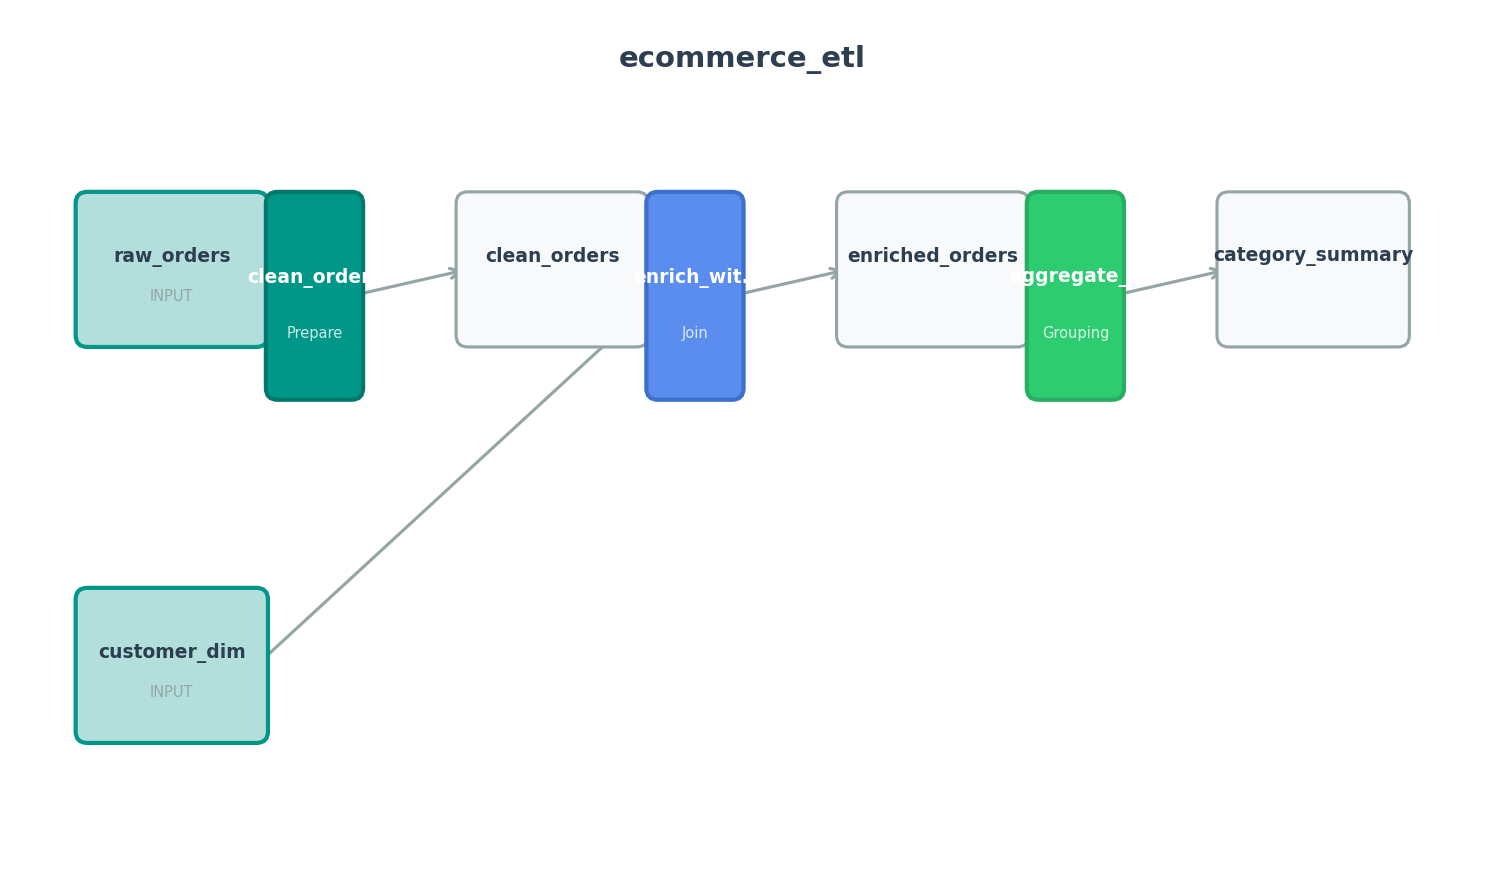

In [34]:
# PNG export - publication-quality diagram
from py2dataiku.visualizers import MatplotlibVisualizer
from IPython.display import Image, display

viz = MatplotlibVisualizer()
png_bytes = viz.render(etl_flow)
display(Image(png_bytes))

### Flow Zone Visualization

Assign datasets and recipes to named `FlowZone` groups. Zones appear as color-coded dashed regions in SVG and PNG diagrams, and as `subgraph` blocks in Mermaid output.

In [35]:
from py2dataiku.models.dataiku_flow import FlowZone

# Assign nodes to named zones
if etl_flow.datasets and etl_flow.recipes:
    dataset_names = [d.name for d in etl_flow.datasets]
    recipe_names = [r.name for r in etl_flow.recipes]
    
    mid_d = max(1, len(dataset_names) // 2)
    mid_r = max(1, len(recipe_names) // 2)
    
    etl_flow.zones = [
        FlowZone(
            name="Ingestion",
            color="#E3F2FD",
            datasets=dataset_names[:mid_d],
            recipes=recipe_names[:mid_r],
        ),
        FlowZone(
            name="Analysis",
            color="#E8F5E9",
            datasets=dataset_names[mid_d:],
            recipes=recipe_names[mid_r:],
        ),
    ]
    print(f"Assigned {mid_d} datasets and {mid_r} recipes to 'Ingestion' zone")
    print(f"Assigned {len(dataset_names)-mid_d} datasets and {len(recipe_names)-mid_r} recipes to 'Analysis' zone")

Assigned 2 datasets and 1 recipes to 'Ingestion' zone
Assigned 3 datasets and 2 recipes to 'Analysis' zone


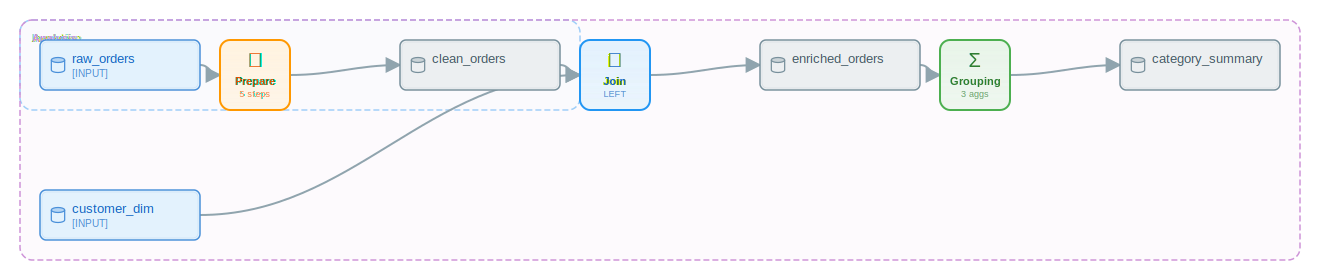

In [36]:
# SVG with zone regions (dashed borders + label badges)
from IPython.display import SVG, display
display(SVG(etl_flow.visualize(format="svg")))

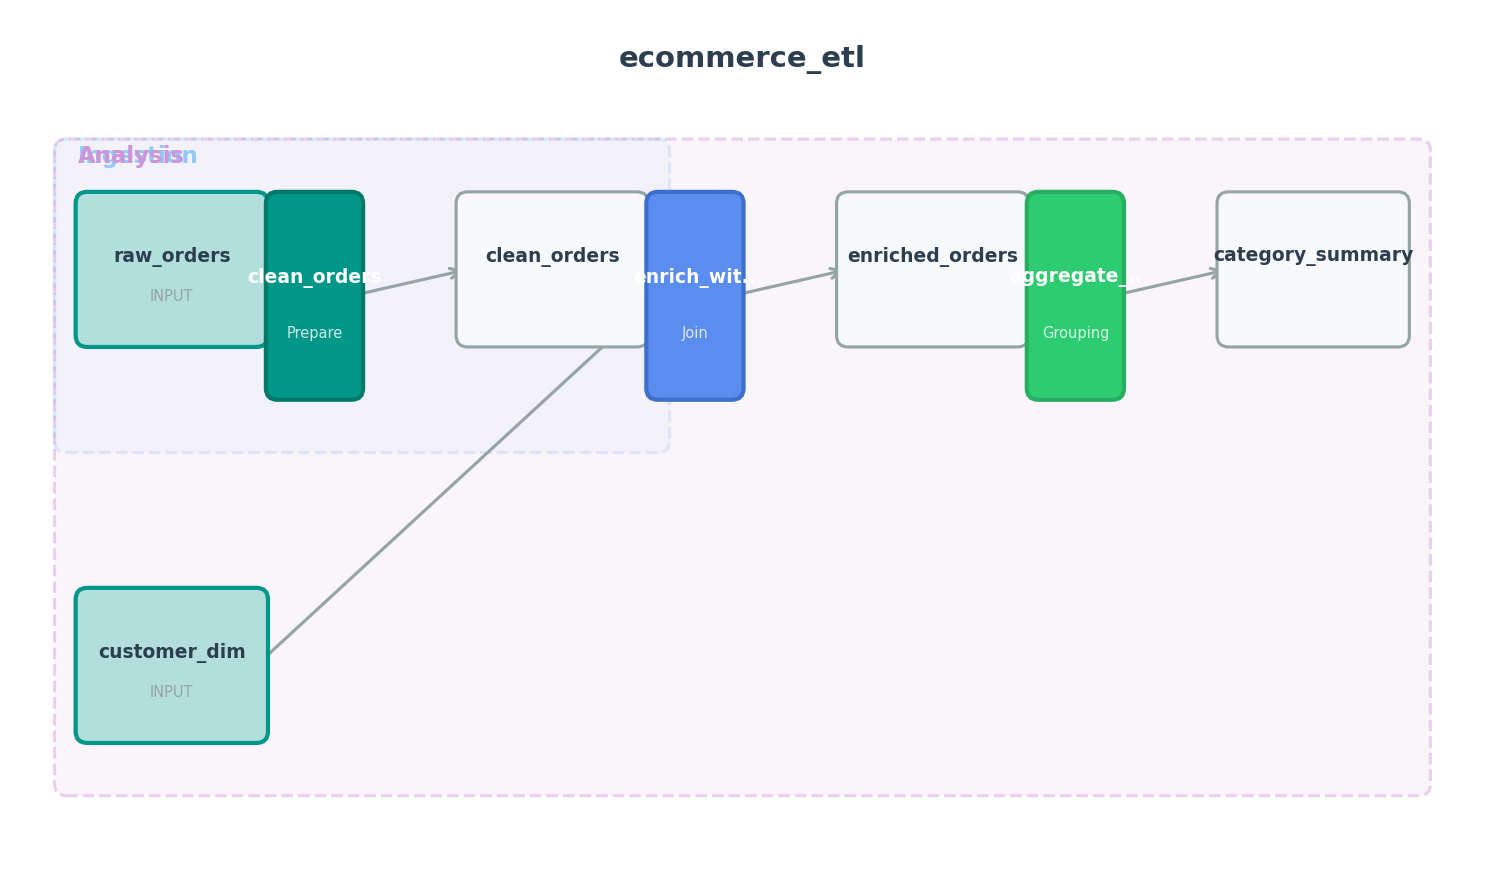

In [37]:
# PNG with zone backgrounds
from py2dataiku.visualizers import MatplotlibVisualizer
from IPython.display import Image, display

png_bytes = MatplotlibVisualizer().render(etl_flow)
display(Image(png_bytes))

In [38]:
# Mermaid diagram for documentation
print(etl_flow.visualize(format='mermaid'))

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(raw_orders)]
        D2[(customer_dim)]
    end
    D1[(clean_orders)]
    D3[(enriched_orders)]
    D4[(category_summary)]
    R0{Prepare\n(5 steps)}
    R1{Join\n(LEFT)}
    R2{Grouping\n(3 aggs)}
    D0 --> R0
    R0 --> D1
    D1 --> R1
    D2 --> R1
    R1 --> D3
    D3 --> R2
    R2 --> D4

    style D0 fill:#e1f5fe
    style D2 fill:#e1f5fe
    style R0 fill:#fff3e0
    style R1 fill:#e3f2fd
    style R2 fill:#e8f5e9


### 7.2 ML Feature Engineering Pipeline

In [39]:
# Convert a pandas ML feature engineering script
ml_code = '''
import pandas as pd
import numpy as np

# Load data
transactions = pd.read_csv('transactions.csv')
customers = pd.read_csv('customers.csv')

# Clean transaction data
transactions = transactions.dropna(subset=['amount', 'merchant_id'])
transactions['amount'] = transactions['amount'].astype(float)

# Feature engineering
transactions['log_amount'] = np.log1p(transactions['amount'])
transactions['merchant_id'] = transactions['merchant_id'].str.upper()

# Aggregate features per customer
customer_features = transactions.groupby('customer_id').agg({
    'amount': ['sum', 'mean', 'std', 'count'],
    'merchant_id': 'nunique'
})

# Merge with customer demographics
features = pd.merge(customer_features, customers, left_index=True, right_on='id')

# Sort by total spend
features = features.sort_values('amount_sum', ascending=False)
'''

ml_flow = convert(ml_code)
print(f"ML Feature Engineering flow: {ml_flow.name}")
print(f"  Datasets: {len(ml_flow.datasets)}")
print(f"  Recipes: {len(ml_flow.recipes)}")
for r in ml_flow.recipes:
    print(f"    {r.name} ({r.recipe_type.value}): {r.inputs} -> {r.outputs}")
    if r.steps:
        for step in r.steps:
            print(f"      - {step.get_description()}")

ML Feature Engineering flow: converted_flow
  Datasets: 7
  Recipes: 5
    prepare_merged_prepare_1 (prepare): ['transactions'] -> ['transactions_prepared_prepared']
      - Set type of 'amount' to float
      - Remove rows with empty values in: amount, merchant_id
    prepare_3 (prepare): ['transactions_prepared'] -> ['transactions_prepared_prepared']
      - NumericalTransformer: {'column': 'unknown', 'mode': ''}
    grouping_4 (grouping): ['transactions_prepared'] -> ['customer_features']
    join_5 (join): ['customer_features', 'customers'] -> ['features']
    sort_6 (sort): ['features'] -> ['features_sorted']


### ML Feature Engineering Visualization

Visualize the converted ML pipeline in ASCII and Mermaid formats.

In [40]:
# ASCII visualization of the ML feature engineering pipeline
print(ml_flow.visualize(format='ascii'))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 transactions   │
                             │    [INPUT]        │
                              └──────────────────┘

                          ┌─────────────────────────┐
                          │ 📊 transactions_prepared │
                          └─────────────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   Σ GROUPING  │
                          

In [41]:
# Mermaid visualization of the ML feature engineering pipeline
print(ml_flow.visualize(format='mermaid'))

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(transactions)]
        D2[(customers)]
    end
    D1[(transactions_prepared)]
    D3[(transactions_prepared_prepared)]
    D4[(customer_features)]
    D5[(features)]
    D6[(features_sorted)]
    R0{Prepare\n(2 steps)}
    R1{Prepare\n(1 steps)}
    R2{Grouping\n(1 aggs)}
    R3{Join\n(INNER)}
    R4{Sort}
    D0 --> R0
    R0 --> D3
    D1 --> R1
    R1 --> D3
    D1 --> R2
    R2 --> D4
    D4 --> R3
    D2 --> R3
    R3 --> D5
    D5 --> R4
    R4 --> D6

    style D0 fill:#e1f5fe
    style D2 fill:#e1f5fe
    style R0 fill:#fff3e0
    style R1 fill:#fff3e0
    style R2 fill:#e8f5e9
    style R3 fill:#e3f2fd
    style R4 fill:#f5f5f5


### 7.3 Data Quality Pipeline

In [42]:
# Build a data quality monitoring pipeline
dq_flow = DataikuFlow(name="data_quality_pipeline")

# Step 1: Prepare recipe with validation processors
validate_recipe = DataikuRecipe.create_prepare(
    name="validate_input",
    input_dataset="raw_data",
    output_dataset="validated_data",
    steps=[
        # Remove rows with missing critical fields
        PrepareStep.remove_rows_on_empty(columns=["id", "email", "amount"]),
        # Validate email format
        PrepareStep.filter_on_value(
            column="email",
            values=["@"],
            matching_mode="CONTAINS",
            keep=True,
        ),
        # Flag suspicious amounts
        PrepareStep.if_then_else(
            column="amount",
            condition="amount > 100000",
            then_value="SUSPICIOUS",
            else_value="NORMAL",
            output_column="amount_flag",
        ),
        # Deduplicate
        PrepareStep.remove_duplicates(columns=["id"]),
    ],
)
dq_flow.add_recipe(validate_recipe)

# Define quality metrics for the validated dataset
dq_metrics = [
    DataikuMetric.row_count(),
    DataikuMetric.column_missing("email"),
    DataikuMetric.column_missing("amount"),
    DataikuMetric.column_min("amount"),
    DataikuMetric.column_max("amount"),
    DataikuMetric.column_avg("amount"),
]

# Define quality checks
dq_checks = [
    DataikuCheck.not_empty("has_data", "row_count"),
    DataikuCheck.between("email_completeness", "email_missing", 0, 10, severity=CheckSeverity.WARNING),
    DataikuCheck(
        name="positive_amounts",
        metric_name="amount_min",
        condition=CheckCondition.GREATER_THAN,
        value=0,
        severity=CheckSeverity.ERROR,
    ),
]

# Quality rules for column-level validation
dq_rules = [
    DataQualityRule.not_null("id"),
    DataQualityRule.unique("id"),
    DataQualityRule.in_range("amount", 0.01, 100000),
    DataQualityRule.regex_match("email", r"^[\w.+-]+@[\w-]+\.[\w.]+$"),
    DataQualityRule.in_set("status", ["active", "inactive", "pending"]),
]

print(f"Data Quality Pipeline:")
print(f"  Metrics defined: {len(dq_metrics)}")
print(f"  Checks defined: {len(dq_checks)}")
print(f"  Quality rules: {len(dq_rules)}")

# Scenario to automate quality checks
dq_scenario = DataikuScenario(name="quality_monitor", tags=["data-quality"])
dq_scenario.add_trigger(ScenarioTrigger.dataset_change("on_raw_data", "raw_data"))
dq_scenario.add_step(ScenarioStep.build("Build validated", dataset="validated_data"))
dq_scenario.add_step(ScenarioStep.run_checks("Run quality checks", dataset="validated_data"))
dq_scenario.add_reporter(ScenarioReporter.email(
    "Quality report",
    recipients=["data-quality@company.com"],
    subject="Data Quality Alert",
))

print(f"\nAutomation scenario: {repr(dq_scenario)}")

Data Quality Pipeline:
  Metrics defined: 6
  Checks defined: 3
  Quality rules: 5

Automation scenario: DataikuScenario(name='quality_monitor', triggers=1, steps=2, reporters=1)


---
## End-to-End Use Case Showcase

These examples demonstrate the full py-iku pipeline: **Python data script -> optimized Dataiku flow -> API-ready output**.

Each example follows the complete journey:
1. The original Python code
2. Rule-based conversion with `convert()`
3. Flow summary and recipe inspection
4. ASCII and Mermaid visualizations
5. API-ready recipe configs via `to_recipe_configs()`
6. Validation

This is the core use case for Phase 2 MCP integration: generating Dataiku-compatible configurations from Python code.

### Use Case 1: E-commerce Analytics Pipeline

A realistic scenario: an analyst has a Python script that loads order and customer CSVs,
cleans data, joins tables, aggregates by region, and extracts top performers.
py-iku converts this into an optimized Dataiku flow ready for production deployment.

In [43]:
import json

# Step 1: The Python code
ecommerce_code = """
import pandas as pd

orders = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')

# Clean order data
orders = orders.dropna()
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['amount'] = orders['amount'].astype(float)

# Join with customer info
merged = pd.merge(orders, customers, on='customer_id')

# Aggregate by region
summary = merged.groupby('region').agg({'amount': 'sum', 'order_id': 'count'})

# Top 10 regions by revenue
top = summary.nlargest(10, 'amount')
top.to_csv('top_regions.csv')
"""

# Step 2: Convert with optimization
ecom_flow = convert(ecommerce_code, optimize=True)

# Step 3: Flow summary and recipe inspection
print("=" * 60)
print("E-COMMERCE ANALYTICS PIPELINE")
print("=" * 60)
print(f"\nRecipes: {len(ecom_flow.recipes)}")
print(f"Datasets: {len(ecom_flow.datasets)}")
print(f"Recipe types: {[r.recipe_type.value for r in ecom_flow.recipes]}")
print()

# Show how each Python operation mapped to Dataiku
print("Python -> Dataiku Mapping:")
for r in ecom_flow.recipes:
    step_detail = ""
    if r.steps:
        step_detail = f" [{', '.join(s.processor_type.value for s in r.steps)}]"
    print(f"  {r.recipe_type.value}: {r.inputs} -> {r.outputs}{step_detail}")

# Step 6: Validation
validation = ecom_flow.validate()
print(f"\nValidation: {'PASSED' if validation['valid'] else 'FAILED'}")
print(f"  Errors: {len(validation['errors'])}")
print(f"  Warnings: {len(validation['warnings'])}")

E-COMMERCE ANALYTICS PIPELINE

Recipes: 4
Datasets: 7
Recipe types: ['prepare', 'join', 'grouping', 'topn']

Python -> Dataiku Mapping:
  prepare: ['orders'] -> ['orders_prepared_prepared'] [TypeSetter, RemoveRowsOnEmpty]
  join: ['orders_prepared', 'customers'] -> ['merged']
  grouping: ['merged'] -> ['summary']
  topn: ['summary'] -> ['summary_topn']

Validation: PASSED
  Errors: 0
  Warnings: 1


In [44]:
# Step 4: ASCII visualization
print(ecom_flow.visualize(format="ascii"))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                             ┌───────────────────┐
                             │ 📊 orders_prepared │
                             └───────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⋈ JOIN      │
                                │ ─

In [45]:
# Step 4b: Mermaid visualization (documentation-ready)
print(ecom_flow.visualize(format="mermaid"))

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(orders)]
        D2[(customers)]
    end
    subgraph outputs[Output Datasets]
        D6[(summary_topn)]
    end
    D1[(orders_prepared)]
    D3[(orders_prepared_prepared)]
    D4[(merged)]
    D5[(summary)]
    R0{Prepare\n(2 steps)}
    R1{Join\n(INNER)}
    R2{Grouping\n(2 aggs)}
    R3{Topn}
    D0 --> R0
    R0 --> D3
    D1 --> R1
    D2 --> R1
    R1 --> D4
    D4 --> R2
    R2 --> D5
    D5 --> R3
    R3 --> D6

    style D0 fill:#e1f5fe
    style D2 fill:#e1f5fe
    style D6 fill:#c8e6c9
    style R0 fill:#fff3e0
    style R1 fill:#e3f2fd
    style R2 fill:#e8f5e9
    style R3 fill:#efebe9


In [46]:
# Step 5: API-ready recipe configurations via to_recipe_configs()
# This is the output that Phase 2 MCP integration consumes
configs = ecom_flow.to_recipe_configs()
print(f"Generated {len(configs)} API-ready recipe configs\n")

for i, config in enumerate(configs):
    print(f"--- Recipe Config {i+1}: {config['type']} ---")
    print(json.dumps(config, indent=2)[:400])
    if len(json.dumps(config)) > 400:
        print("  ...")
    print()

Generated 4 API-ready recipe configs

--- Recipe Config 1: shaker ---
{
  "type": "shaker",
  "name": "prepare_merged_prepare_1",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "orders",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "orders_prepared_prepared",
          "appendMode": false
        }
      ]
    }
  },
  "versionTag": {
    "versionNumber": 
  ...

--- Recipe Config 2: join ---
{
  "type": "join",
  "name": "join_3",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "orders_prepared",
          "appendMode": false
        },
        {
          "ref": "customers",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "merged",
          "appendMode": false
        }
      
  ...

--- Recipe Config 3: grouping ---
{
  "type": "grouping",
  "name": "grouping_4",
  

### Use Case 2: Data Quality Pipeline

A common data engineering task: cleaning raw input data with string normalization,
type conversion, filtering, and deduplication. Each Python operation maps to a specific
Dataiku recipe or processor type.

In [47]:
# Step 1: The Python data quality script
quality_code = """
import pandas as pd

df = pd.read_csv('raw_data.csv')

# String cleaning
df['name'] = df['name'].str.strip()
df['name'] = df['name'].str.title()
df['email'] = df['email'].str.lower()

# Type conversion
df['age'] = df['age'].astype(int)
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Filter invalid records
df = df[df['age'] >= 18]

# Deduplication
df = df.drop_duplicates(subset=['email'])

df.to_csv('clean_data.csv', index=False)
"""

# Step 2: Convert
quality_flow = convert(quality_code, optimize=True)

# Step 3: Summary and mapping
print("=" * 60)
print("DATA QUALITY PIPELINE")
print("=" * 60)
print(f"\nRecipes: {len(quality_flow.recipes)}")
print(f"Datasets: {len(quality_flow.datasets)}")
print()

print("Python -> Dataiku Mapping:")
print("  str.strip() + str.title() + str.lower() -> PREPARE (StringTransformer)")
print("  astype(int) -> PREPARE (TypeSetter)")
print("  pd.to_datetime() -> PREPARE (DateParser)")
print("  df[condition] -> SPLIT (filter)")
print("  drop_duplicates() -> PREPARE (RemoveDuplicates)")
print()

for r in quality_flow.recipes:
    step_detail = ""
    if r.steps:
        step_detail = f" [{', '.join(s.processor_type.value for s in r.steps)}]"
    print(f"  {r.recipe_type.value}: {r.inputs} -> {r.outputs}{step_detail}")

# Validation
validation = quality_flow.validate()
print(f"\nValidation: {'PASSED' if validation['valid'] else 'FAILED'}")

DATA QUALITY PIPELINE

Recipes: 2
Datasets: 3

Python -> Dataiku Mapping:
  str.strip() + str.title() + str.lower() -> PREPARE (StringTransformer)
  astype(int) -> PREPARE (TypeSetter)
  pd.to_datetime() -> PREPARE (DateParser)
  df[condition] -> SPLIT (filter)
  drop_duplicates() -> PREPARE (RemoveDuplicates)

  split: ['df'] -> ['df_filtered']
  prepare: ['df_filtered'] -> ['df_filtered_prepared_prepared'] [TypeSetter, RemoveDuplicates]

Validation: PASSED


In [48]:
# Step 4: Visualizations
print(quality_flow.visualize(format="ascii"))
print()
print(quality_flow.visualize(format="mermaid"))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⑂ SPLIT     │
                                │ ──────────── │
                                │ filter       │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 df_filtered    │
                              └──────────────────┘

         

In [49]:
# Step 5: API-ready output
quality_configs = quality_flow.to_recipe_configs()
print(f"Generated {len(quality_configs)} API-ready recipe configs\n")
for config in quality_configs:
    print(f"--- {config['type']} ---")
    print(json.dumps(config, indent=2)[:300])
    if len(json.dumps(config)) > 300:
        print("  ...")
    print()

Generated 2 API-ready recipe configs

--- split ---
{
  "type": "split",
  "name": "split_1",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "df",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "df_filtered",
          "appendMode": false
   

--- shaker ---
{
  "type": "shaker",
  "name": "prepare_merged_prepare_2",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "df_filtered",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "df_filtered_prepared
  ...



### Use Case 3: Feature Engineering Pipeline

A data scientist's feature engineering script: joining transaction and user data,
computing aggregates, sorting, and extracting top records. This demonstrates how
py-iku maps JOIN, GROUPING, SORT, and TOP_N recipes from pandas code.

In [50]:
# Step 1: The Python feature engineering script
feature_code = """
import pandas as pd
import numpy as np

transactions = pd.read_csv('transactions.csv')
users = pd.read_csv('users.csv')

# Clean
transactions = transactions.dropna()
transactions['amount'] = transactions['amount'].astype(float)

# Join transactions with user profiles
features = pd.merge(transactions, users, on='user_id')

# Aggregate per user
agg = features.groupby('user_id').agg({
    'amount': ['sum', 'mean', 'count'],
    'category': 'nunique'
})

# Sort by total spend
agg = agg.sort_values(('amount', 'sum'), ascending=False)

# Top 100 users
top = agg.nlargest(100, ('amount', 'sum'))
"""

# Step 2: Convert
feature_flow = convert(feature_code, optimize=True)

# Step 3: Summary
print("=" * 60)
print("FEATURE ENGINEERING PIPELINE")
print("=" * 60)
print(f"\nRecipes: {len(feature_flow.recipes)}")
print(f"Datasets: {len(feature_flow.datasets)}")
print(f"Recipe types: {[r.recipe_type.value for r in feature_flow.recipes]}")
print()

print("Python -> Dataiku Mapping:")
print("  dropna() + astype(float) -> PREPARE (RemoveRowsOnEmpty + TypeSetter)")
print("  pd.merge() -> JOIN")
print("  groupby().agg() -> GROUPING")
print("  sort_values() -> SORT")
print("  nlargest() -> TOP_N")
print()

for r in feature_flow.recipes:
    step_detail = ""
    if r.steps:
        step_detail = f" [{', '.join(s.processor_type.value for s in r.steps)}]"
    print(f"  {r.recipe_type.value}: {r.inputs} -> {r.outputs}{step_detail}")

# Validation
validation = feature_flow.validate()
print(f"\nValidation: {'PASSED' if validation['valid'] else 'FAILED'}")

FEATURE ENGINEERING PIPELINE

Recipes: 5
Datasets: 8
Recipe types: ['prepare', 'join', 'grouping', 'sort', 'topn']

Python -> Dataiku Mapping:
  dropna() + astype(float) -> PREPARE (RemoveRowsOnEmpty + TypeSetter)
  pd.merge() -> JOIN
  groupby().agg() -> GROUPING
  sort_values() -> SORT
  nlargest() -> TOP_N

  prepare: ['transactions'] -> ['transactions_prepared_prepared'] [TypeSetter, RemoveRowsOnEmpty]
  join: ['transactions_prepared', 'users'] -> ['features']
  grouping: ['features'] -> ['agg']
  sort: ['agg'] -> ['agg_sorted']
  topn: ['agg_sorted'] -> ['agg_sorted_topn']

Validation: PASSED


In [51]:
# Step 4: Visualizations
print(feature_flow.visualize(format="ascii"))
print()
print(feature_flow.visualize(format="mermaid"))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                          ┌─────────────────────────┐
                          │ 📊 transactions_prepared │
                          └─────────────────────────┘

                              ┌──────────────────┐
                              │ 📊 users          │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 transactions   │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⋈ JOIN      │
                          

In [52]:
# Step 5: API-ready output
feature_configs = feature_flow.to_recipe_configs()
print(f"Generated {len(feature_configs)} API-ready recipe configs\n")
for config in feature_configs:
    print(f"--- {config['type']} ---")
    print(json.dumps(config, indent=2)[:300])
    if len(json.dumps(config)) > 300:
        print("  ...")
    print()

Generated 5 API-ready recipe configs

--- shaker ---
{
  "type": "shaker",
  "name": "prepare_merged_prepare_1",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "transactions",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "transactions_prepar
  ...

--- join ---
{
  "type": "join",
  "name": "join_3",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "transactions_prepared",
          "appendMode": false
        },
        {
          "ref": "users",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": 
  ...

--- grouping ---
{
  "type": "grouping",
  "name": "grouping_4",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "features",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "agg",
          "appendMode": false


---
## 8. Grand Finale: Complete Production ML System

This section builds a comprehensive multi-zone production ML system with:
- Multi-zone flow organization
- Complex recipe chains
- Scenario automation
- Metrics and quality monitoring
- MLOps deployment configuration
- Full visualization

In [53]:
# Build the complete production flow
from py2dataiku.models.dataiku_flow import DataikuFlow, FlowZone
from py2dataiku.models.dataiku_recipe import (
    DataikuRecipe, RecipeType, Aggregation, JoinKey, JoinType,
    AggregationFunction, WindowFunctionType, SamplingMethod,
)
from py2dataiku.models.dataiku_dataset import DataikuDataset, DatasetType
from py2dataiku.models.prepare_step import PrepareStep, ProcessorType, StringTransformerMode

prod_flow = DataikuFlow(name="production_fraud_detection")

# ===== ZONE 1: Data Ingestion =====
ingestion_zone = FlowZone(
    name="Data Ingestion",
    color="#3498db",
)

# Clean raw transactions
clean_txn = DataikuRecipe.create_prepare(
    name="clean_transactions",
    input_dataset="raw_transactions",
    output_dataset="clean_transactions",
    steps=[
        PrepareStep.remove_rows_on_empty(columns=["transaction_id", "amount", "customer_id"]),
        PrepareStep.fill_empty("merchant_category", "UNKNOWN"),
        PrepareStep.string_transform("merchant_name", StringTransformerMode.TRIM),
        PrepareStep.string_transform("merchant_name", StringTransformerMode.UPPERCASE),
        PrepareStep.parse_date("transaction_date", formats=["%Y-%m-%dT%H:%M:%S"]),
        PrepareStep.set_type("amount", "double"),
    ],
)
prod_flow.add_recipe(clean_txn)
ingestion_zone.add_recipe("clean_transactions")
ingestion_zone.add_dataset("raw_transactions")
ingestion_zone.add_dataset("clean_transactions")

# Enrich with customer data
enrich_recipe = DataikuRecipe.create_join(
    name="join_customer_data",
    left_dataset="clean_transactions",
    right_dataset="customer_profiles",
    output_dataset="enriched_transactions",
    join_keys=[JoinKey(left_column="customer_id", right_column="customer_id")],
    join_type=JoinType.LEFT,
)
prod_flow.add_recipe(enrich_recipe)
ingestion_zone.add_recipe("join_customer_data")
ingestion_zone.add_dataset("customer_profiles")
ingestion_zone.add_dataset("enriched_transactions")

prod_flow.zones.append(ingestion_zone)
print(f"Zone 1 ({ingestion_zone.name}): {len(ingestion_zone.recipes)} recipes, {len(ingestion_zone.datasets)} datasets")

Zone 1 (Data Ingestion): 2 recipes, 4 datasets


In [54]:
# ===== ZONE 2: Feature Engineering =====
feature_zone = FlowZone(name="Feature Engineering", color="#2ecc71")

# Aggregate features per customer
customer_agg = DataikuRecipe.create_grouping(
    name="customer_aggregates",
    input_dataset="enriched_transactions",
    output_dataset="customer_features",
    keys=["customer_id"],
    aggregations=[
        Aggregation(column="amount", function=AggregationFunction.SUM.value, output_column="total_spend"),
        Aggregation(column="amount", function=AggregationFunction.AVG.value, output_column="avg_transaction"),
        Aggregation(column="amount", function=AggregationFunction.STDDEV.value, output_column="spend_volatility"),
        Aggregation(column="transaction_id", function=AggregationFunction.COUNT.value, output_column="transaction_count"),
        Aggregation(column="merchant_category", function=AggregationFunction.COUNTD.value, output_column="unique_merchants"),
        Aggregation(column="amount", function=AggregationFunction.MAX.value, output_column="max_transaction"),
        Aggregation(column="amount", function=AggregationFunction.PERCENTILE_95.value, output_column="p95_amount"),
    ],
)
prod_flow.add_recipe(customer_agg)
feature_zone.add_recipe("customer_aggregates")
feature_zone.add_dataset("customer_features")

# Window function for velocity features
velocity_recipe = DataikuRecipe(
    name="transaction_velocity",
    recipe_type=RecipeType.WINDOW,
    inputs=["enriched_transactions"],
    outputs=["velocity_features"],
    partition_columns=["customer_id"],
    order_columns=["transaction_date"],
    window_aggregations=[
        {"column": "amount", "type": WindowFunctionType.LAG.value, "offset": 1, "output": "prev_amount"},
        {"column": "amount", "type": WindowFunctionType.LAG_DIFF.value, "offset": 1, "output": "amount_change"},
        {"column": "amount", "type": WindowFunctionType.RUNNING_AVG.value, "output": "running_avg_amount"},
        {"column": "amount", "type": WindowFunctionType.MOVING_STDDEV.value, "window_size": 10, "output": "moving_stddev"},
        {"column": "transaction_id", "type": WindowFunctionType.ROW_NUMBER.value, "output": "txn_sequence"},
        {"column": "amount", "type": WindowFunctionType.RANK.value, "output": "amount_rank"},
    ],
)
prod_flow.add_recipe(velocity_recipe)
feature_zone.add_recipe("transaction_velocity")
feature_zone.add_dataset("velocity_features")

# Join customer features with velocity features
feature_join = DataikuRecipe.create_join(
    name="combine_features",
    left_dataset="velocity_features",
    right_dataset="customer_features",
    output_dataset="final_features",
    join_keys=[JoinKey(left_column="customer_id", right_column="customer_id")],
    join_type=JoinType.LEFT,
)
prod_flow.add_recipe(feature_join)
feature_zone.add_recipe("combine_features")
feature_zone.add_dataset("final_features")

prod_flow.zones.append(feature_zone)
print(f"Zone 2 ({feature_zone.name}): {len(feature_zone.recipes)} recipes, {len(feature_zone.datasets)} datasets")

Zone 2 (Feature Engineering): 3 recipes, 3 datasets


In [55]:
# ===== ZONE 3: Training & Scoring =====
ml_zone = FlowZone(name="ML Training & Scoring", color="#9b59b6")

# Sample for training
sample_recipe = DataikuRecipe(
    name="sample_training_data",
    recipe_type=RecipeType.SAMPLING,
    inputs=["final_features"],
    outputs=["training_sample"],
    sampling_method=SamplingMethod.STRATIFIED,
    sample_size=50000,
)
prod_flow.add_recipe(sample_recipe)
ml_zone.add_recipe("sample_training_data")
ml_zone.add_dataset("training_sample")

# Python recipe for model training
train_recipe = DataikuRecipe.create_python(
    name="train_fraud_model",
    inputs=["training_sample"],
    outputs=["model_metrics"],
    code="""import dataiku
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

train_df = dataiku.Dataset('training_sample').get_dataframe()
X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']

model = GradientBoostingClassifier(n_estimators=200, max_depth=5)
scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
model.fit(X, y)
""",
)
prod_flow.add_recipe(train_recipe)
ml_zone.add_recipe("train_fraud_model")
ml_zone.add_dataset("model_metrics")

# Scoring recipe
scoring_recipe = DataikuRecipe(
    name="score_transactions",
    recipe_type=RecipeType.PREDICTION_SCORING,
    inputs=["final_features"],
    outputs=["scored_transactions"],
)
prod_flow.add_recipe(scoring_recipe)
ml_zone.add_recipe("score_transactions")
ml_zone.add_dataset("scored_transactions")

prod_flow.zones.append(ml_zone)
print(f"Zone 3 ({ml_zone.name}): {len(ml_zone.recipes)} recipes, {len(ml_zone.datasets)} datasets")

Zone 3 (ML Training & Scoring): 3 recipes, 3 datasets


In [56]:
# ===== ZONE 4: Output & Reporting =====
output_zone = FlowZone(name="Output & Reporting", color="#e74c3c")

# Distinct recipe for final deduplication
distinct_recipe = DataikuRecipe(
    name="deduplicate_scores",
    recipe_type=RecipeType.DISTINCT,
    inputs=["scored_transactions"],
    outputs=["unique_scores"],
)
prod_flow.add_recipe(distinct_recipe)
output_zone.add_recipe("deduplicate_scores")
output_zone.add_dataset("unique_scores")

# Sort by fraud probability for review
sort_recipe = DataikuRecipe(
    name="sort_by_risk",
    recipe_type=RecipeType.SORT,
    inputs=["unique_scores"],
    outputs=["fraud_alerts"],
    sort_columns=[{"column": "fraud_probability", "order": "DESC"}],
)
prod_flow.add_recipe(sort_recipe)
output_zone.add_recipe("sort_by_risk")
output_zone.add_dataset("fraud_alerts")

# Top N for immediate review
topn_recipe = DataikuRecipe(
    name="top_fraud_cases",
    recipe_type=RecipeType.TOP_N,
    inputs=["fraud_alerts"],
    outputs=["top_100_fraud_cases"],
    top_n=100,
    ranking_column="fraud_probability",
)
prod_flow.add_recipe(topn_recipe)
output_zone.add_recipe("top_fraud_cases")
output_zone.add_dataset("top_100_fraud_cases")

prod_flow.zones.append(output_zone)
print(f"Zone 4 ({output_zone.name}): {len(output_zone.recipes)} recipes, {len(output_zone.datasets)} datasets")

Zone 4 (Output & Reporting): 3 recipes, 3 datasets


In [57]:
# ===== Metrics & Quality Checks =====
prod_metrics = [
    DataikuMetric.row_count("scored_row_count"),
    DataikuMetric.column_avg("fraud_probability", name="avg_fraud_score"),
    DataikuMetric.column_max("fraud_probability", name="max_fraud_score"),
    DataikuMetric.column_missing("fraud_probability", name="missing_scores"),
    DataikuMetric.column_min("amount", name="min_amount"),
    DataikuMetric.custom_sql(
        "high_risk_count",
        "SELECT COUNT(*) FROM scored_transactions WHERE fraud_probability > 0.8",
    ),
]

prod_checks = [
    DataikuCheck.not_empty("output_has_data", "scored_row_count"),
    DataikuCheck.between("fraud_rate_normal", "avg_fraud_score", 0.001, 0.1, severity=CheckSeverity.WARNING),
    DataikuCheck(
        name="no_missing_scores",
        metric_name="missing_scores",
        condition=CheckCondition.EQUALS,
        value=0,
        severity=CheckSeverity.ERROR,
    ),
]

prod_rules = [
    DataQualityRule.not_null("transaction_id"),
    DataQualityRule.unique("transaction_id"),
    DataQualityRule.in_range("fraud_probability", 0.0, 1.0),
    DataQualityRule.in_range("amount", 0.01, 1000000),
]

print(f"Production monitoring:")
print(f"  Metrics: {len(prod_metrics)}")
for m in prod_metrics:
    print(f"    {m.name}: {m.metric_type.value}")
print(f"  Checks: {len(prod_checks)}")
for c in prod_checks:
    print(f"    {c.name}: {c.condition.value} ({c.severity.value})")
print(f"  Quality rules: {len(prod_rules)}")

Production monitoring:
  Metrics: 6
    scored_row_count: row_count
    avg_fraud_score: column_avg
    max_fraud_score: column_max
    missing_scores: column_missing
    min_amount: column_min
    high_risk_count: custom_sql
  Checks: 3
    output_has_data: not_empty (ERROR)
    fraud_rate_normal: between (WARNING)
    no_missing_scores: equals (ERROR)
  Quality rules: 4


In [58]:
# ===== MLOps Configuration =====
# Active model version
active_model = ModelVersion(
    version_id="v2.3.1",
    model_name="fraud_detector",
    framework=ModelFramework.XGBOOST,
    algorithm="XGBClassifier",
    metrics={"accuracy": 0.965, "f1": 0.931, "auc_roc": 0.982, "precision": 0.94, "recall": 0.92},
    features=["total_spend", "avg_transaction", "spend_volatility", "transaction_count",
              "unique_merchants", "max_transaction", "p95_amount", "prev_amount",
              "amount_change", "running_avg_amount", "moving_stddev"],
    target="is_fraud",
    active=True,
    tags=["production", "champion", "v2"],
)

# API endpoint
api = APIEndpoint(
    name="fraud_detection_api",
    model_name="fraud_detector",
    endpoint_type=EndpointType.REST,
    url_path="/api/v2/fraud/predict",
    input_schema={"transaction_id": "string", "amount": "float", "customer_id": "string",
                  "merchant_category": "string", "is_international": "boolean"},
    output_schema={"fraud_probability": "float", "risk_level": "string", "model_version": "string"},
    auth_required=True,
    rate_limit=5000,
)

# Drift detection
drift = DriftConfig(
    enabled=True,
    metric=DriftMetricType.PSI,
    threshold=0.15,
    columns=["amount", "merchant_category", "transaction_count", "avg_transaction"],
    check_frequency="daily",
)

print("MLOps Configuration:")
print(f"  Active model: {active_model.version_id} ({active_model.framework.value}/{active_model.algorithm})")
print(f"  AUC-ROC: {active_model.metrics['auc_roc']}")
print(f"  Features: {len(active_model.features)}")
print(f"  API: {api.url_path} (rate limit: {api.rate_limit}/min)")
print(f"  Drift: {drift.metric.value}, threshold={drift.threshold}, freq={drift.check_frequency}")

MLOps Configuration:
  Active model: v2.3.1 (xgboost/XGBClassifier)
  AUC-ROC: 0.982
  Features: 11
  API: /api/v2/fraud/predict (rate limit: 5000/min)
  Drift: psi, threshold=0.15, freq=daily


In [59]:
# ===== Production Scenario =====
prod_scenario = DataikuScenario(
    name="fraud_detection_production",
    active=True,
    tags=["production", "ml", "fraud-detection", "critical"],
)

# Triggers: run on new data and nightly retraining
prod_scenario.add_trigger(ScenarioTrigger.dataset_change("on_new_transactions", "raw_transactions"))
prod_scenario.add_trigger(ScenarioTrigger.time_based("nightly_retrain", "0 3 * * *", timezone="UTC"))

# Steps in execution order
prod_scenario.add_step(ScenarioStep.build("Build clean data", dataset="clean_transactions"))
prod_scenario.add_step(ScenarioStep.build("Build features", dataset="final_features"))
prod_scenario.add_step(ScenarioStep.train("Retrain model", model_id="fraud_detector_v2"))
prod_scenario.add_step(ScenarioStep.build("Score transactions", dataset="scored_transactions"))
prod_scenario.add_step(ScenarioStep.run_checks("Validate output", dataset="scored_transactions"))
prod_scenario.add_step(ScenarioStep.build("Generate alerts", dataset="top_100_fraud_cases"))
prod_scenario.add_step(ScenarioStep.execute_python(
    "Drift check",
    code="from drift_monitor import check_drift\ncheck_drift('scored_transactions', threshold=0.15)",
))
prod_scenario.add_step(ScenarioStep.send_message(
    "Alert on high fraud",
    channel="#fraud-ops",
    message="New batch scored. Check top_100_fraud_cases for high-risk transactions.",
))

# Reporters
prod_scenario.add_reporter(ScenarioReporter.email(
    "Ops team", ["fraud-ops@company.com"], subject="Fraud Detection Pipeline Report",
))
prod_scenario.add_reporter(ScenarioReporter.slack(
    "Slack ops", "#fraud-ops", "https://example.com/slack-webhook-placeholder",
))
pagerduty = ScenarioReporter.webhook("PagerDuty", "https://events.pagerduty.com/v2/enqueue")
pagerduty.on_success = False  # Only on failure
prod_scenario.add_reporter(pagerduty)

print(repr(prod_scenario))
print(f"  Triggers: {len(prod_scenario.triggers)}")
print(f"  Steps: {len(prod_scenario.steps)}")
for s in prod_scenario.steps:
    print(f"    {s.name} ({s.step_type.value})")
print(f"  Reporters: {len(prod_scenario.reporters)}")

DataikuScenario(name='fraud_detection_production', triggers=2, steps=8, reporters=3)
  Triggers: 2
  Steps: 8
    Build clean data (build_dataset)
    Build features (build_dataset)
    Retrain model (train_model)
    Score transactions (build_dataset)
    Validate output (run_checks)
    Generate alerts (build_dataset)
    Drift check (execute_python)
    Alert on high fraud (send_message)
  Reporters: 3


In [60]:
# ===== Flow Summary & Visualization =====
print("=" * 70)
print(f"PRODUCTION FLOW: {prod_flow.name}")
print("=" * 70)

# Summary stats
print(f"\nDatasets: {len(prod_flow.datasets)}")
for ds in prod_flow.datasets:
    print(f"  {ds.name} ({ds.dataset_type.value})")

print(f"\nRecipes: {len(prod_flow.recipes)}")
for r in prod_flow.recipes:
    step_info = f", {len(r.steps)} steps" if r.steps else ""
    print(f"  {r.name} ({r.recipe_type.value}){step_info}")

print(f"\nZones: {len(prod_flow.zones)}")
for z in prod_flow.zones:
    print(f"  {z.name} (color={z.color}): {len(z.recipes)} recipes, {len(z.datasets)} datasets")

# DAG analysis
graph = prod_flow.graph
print(f"\nDAG Analysis:")
print(f"  Topological order: {graph.topological_sort()}")
print(f"  Has cycles: {graph.detect_cycles()}")

PRODUCTION FLOW: production_fraud_detection

Datasets: 13
  raw_transactions (input)
  clean_transactions (intermediate)
  customer_profiles (input)
  enriched_transactions (intermediate)
  customer_features (intermediate)
  velocity_features (intermediate)
  final_features (intermediate)
  training_sample (intermediate)
  model_metrics (intermediate)
  scored_transactions (intermediate)
  unique_scores (intermediate)
  fraud_alerts (intermediate)
  top_100_fraud_cases (intermediate)

Recipes: 11
  clean_transactions (prepare), 6 steps
  join_customer_data (join)
  customer_aggregates (grouping)
  transaction_velocity (window)
  combine_features (join)
  sample_training_data (sampling)
  train_fraud_model (python)
  score_transactions (prediction_scoring)
  deduplicate_scores (distinct)
  sort_by_risk (sort)
  top_fraud_cases (topn)

Zones: 4
  Data Ingestion (color=#3498db): 2 recipes, 4 datasets
  Feature Engineering (color=#2ecc71): 3 recipes, 3 datasets
  ML Training & Scoring (col

In [61]:
# Visualize the production flow
ascii_viz = prod_flow.visualize(format="ascii")
print(ascii_viz)

════════════════════════════════════════════════════════════════════════════════
                    DATAIKU FLOW: production_fraud_detection  
════════════════════════════════════════════════════════════════════════════════

                             ┌────────────────────┐
                             │ 📊 raw_transactions │
                            │    [INPUT]          │
                             └────────────────────┘

                            ┌─────────────────────┐
                            │ 📊 customer_profiles │
                            │    [INPUT]           │
                            └─────────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 6 steps      │
                                └──────────────┘

                          

In [62]:
# Mermaid visualization of the production flow
print(prod_flow.visualize(format='mermaid'))

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(raw_transactions)]
        D2[(customer_profiles)]
    end
    D1[(clean_transactions)]
    D3[(enriched_transactions)]
    D4[(customer_features)]
    D5[(velocity_features)]
    D6[(final_features)]
    D7[(training_sample)]
    D8[(model_metrics)]
    D9[(scored_transactions)]
    D10[(unique_scores)]
    D11[(fraud_alerts)]
    D12[(top_100_fraud_cases)]
    R0{Prepare\n(6 steps)}
    R1{Join\n(LEFT)}
    R2{Grouping\n(7 aggs)}
    R3{Window}
    R4{Join\n(LEFT)}
    R5{Sampling}
    R6{Python}
    R7{Prediction_Scoring}
    R8{Distinct}
    R9{Sort}
    R10{Topn}
    D0 --> R0
    R0 --> D1
    D1 --> R1
    D2 --> R1
    R1 --> D3
    D3 --> R2
    R2 --> D4
    D3 --> R3
    R3 --> D5
    D5 --> R4
    D4 --> R4
    R4 --> D6
    D6 --> R5
    R5 --> D7
    D7 --> R6
    R6 --> D8
    D6 --> R7
    R7 --> D9
    D9 --> R8
    R8 --> D10
    D10 --> R9
    R9 --> D11
    D11 --> R10
    R10 --> D12

    style D0 fill:#e

In [63]:
# PlantUML visualization of the production flow
print(prod_flow.visualize(format='plantuml'))

@startuml
!theme plain
skinparam backgroundColor #FAFAFA
skinparam defaultFontName Arial
skinparam defaultFontSize 12

' Dataset styles
skinparam rectangle {
  BackgroundColor<<input>> #E3F2FD
  BorderColor<<input>> #4A90D9
  FontColor<<input>> #1565C0
  BackgroundColor<<output>> #E8F5E9
  BorderColor<<output>> #43A047
  FontColor<<output>> #2E7D32
  BackgroundColor<<intermediate>> #ECEFF1
  BorderColor<<intermediate>> #78909C
  FontColor<<intermediate>> #455A64
}

' Recipe styles
skinparam card {
  BackgroundColor<<prepare>> #FFF3E0
  BorderColor<<prepare>> #FF9800
  BackgroundColor<<join>> #E3F2FD
  BorderColor<<join>> #2196F3
  BackgroundColor<<grouping>> #E8F5E9
  BorderColor<<grouping>> #4CAF50
  BackgroundColor<<split>> #FCE4EC
  BorderColor<<split>> #E91E63
  BackgroundColor<<python>> #E8EAF6
  BorderColor<<python>> #3F51B5
}

' Arrow style
skinparam arrow {
  Color #90A4AE
  Thickness 2
}

' Datasets
rectangle "raw_transactions" <<input>> as raw_transactions
rectangle "customer

### Theme Comparison: DATAIKU_LIGHT vs DATAIKU_DARK

SVG visualizations support theming. Compare the production flow in both built-in themes.

In [64]:
# SVG with DATAIKU_LIGHT theme (default)
from IPython.display import SVG, display
from py2dataiku.visualizers.themes import DATAIKU_LIGHT, DATAIKU_DARK

print("=== DATAIKU_LIGHT Theme ===")
light_svg = prod_flow.visualize(format="svg", theme=DATAIKU_LIGHT)
display(SVG(light_svg))

=== DATAIKU_LIGHT Theme ===


ExpatError: not well-formed (invalid token): line 120, column 70

In [65]:
# SVG with DATAIKU_DARK theme
print("=== DATAIKU_DARK Theme ===")
dark_svg = prod_flow.visualize(format="svg", theme=DATAIKU_DARK)
display(SVG(dark_svg))

=== DATAIKU_DARK Theme ===


ExpatError: not well-formed (invalid token): line 120, column 70

### Jupyter Inline Display with `_repr_svg_()`

DataikuFlow implements `_repr_svg_()`, so Jupyter automatically renders the flow as an SVG when it is the last expression in a cell.

In [66]:
# Jupyter inline display via _repr_svg_() -- just evaluate the flow as the last expression
prod_flow

### Full Format Comparison

Compare all 6 visualization formats on the production flow.

In [67]:
# Compare all visualization formats on the production flow
print(f"{'Format':<15s} {'Output Size':>12s}")
print("=" * 28)
for fmt in ["ascii", "svg", "html", "mermaid", "plantuml", "interactive"]:
    output = prod_flow.visualize(format=fmt)
    print(f"{fmt:<15s} {len(output):>10,d} chars")

# Show the text-based formats
print("\n=== ASCII ===")
print(prod_flow.visualize(format="ascii"))

print("\n=== MERMAID ===")
print(prod_flow.visualize(format="mermaid"))

Format           Output Size
ascii                6,210 chars
svg                 29,820 chars
html                18,789 chars
mermaid              1,318 chars
plantuml             2,976 chars
interactive         42,012 chars

=== ASCII ===
════════════════════════════════════════════════════════════════════════════════
                    DATAIKU FLOW: production_fraud_detection  
════════════════════════════════════════════════════════════════════════════════

                             ┌────────────────────┐
                             │ 📊 raw_transactions │
                            │    [INPUT]          │
                             └────────────────────┘

                            ┌─────────────────────┐
                            │ 📊 customer_profiles │
                            │    [INPUT]           │
                            └─────────────────────┘

                                       │
                                       ▼

                              

### DAG Analysis and Optimization

Analyze the production flow's directed acyclic graph structure.

In [68]:
# DAG analysis of the production flow
dag = prod_flow.graph
print(f"Flow graph: {dag}")
print(f"Dataset nodes: {len(dag.dataset_nodes)}")
print(f"Recipe nodes: {len(dag.recipe_nodes)}")

# Topological sort
print("\nExecution order:")
for i, name in enumerate(dag.topological_sort(), 1):
    node = dag.get_node(name)
    print(f"  {i}. [{node.node_type.value}] {name}")

# Structure
print(f"\nRoot nodes: {dag.get_roots()}")
print(f"Leaf nodes: {dag.get_leaves()}")
print(f"Cycles: {dag.detect_cycles()}")
subgraphs = dag.find_disconnected_subgraphs()
print(f"Connected components: {len(subgraphs)}")
for i, comp in enumerate(subgraphs, 1):
    print(f"  Component {i}: {len(comp)} nodes")

Flow graph: FlowGraph(nodes=24, edges=24)
Dataset nodes: 13
Recipe nodes: 11

Execution order:
  1. [dataset] raw_transactions
  2. [dataset] customer_profiles
  3. [recipe] recipe:clean_transactions
  4. [dataset] clean_transactions
  5. [recipe] recipe:join_customer_data
  6. [dataset] enriched_transactions
  7. [recipe] recipe:customer_aggregates
  8. [recipe] recipe:transaction_velocity
  9. [dataset] customer_features
  10. [dataset] velocity_features
  11. [recipe] recipe:combine_features
  12. [dataset] final_features
  13. [recipe] recipe:sample_training_data
  14. [recipe] recipe:score_transactions
  15. [dataset] training_sample
  16. [dataset] scored_transactions
  17. [recipe] recipe:train_fraud_model
  18. [recipe] recipe:deduplicate_scores
  19. [dataset] model_metrics
  20. [dataset] unique_scores
  21. [recipe] recipe:sort_by_risk
  22. [dataset] fraud_alerts
  23. [recipe] recipe:top_fraud_cases
  24. [dataset] top_100_fraud_cases

Root nodes: ['raw_transactions', 'cus

### Column Lineage Tracing

Trace columns through the production flow to understand data provenance.

In [69]:
# Trace columns through the production flow
for col_name in ["amount", "customer_id", "is_fraud"]:
    lineage = prod_flow.get_column_lineage(col_name)
    print(f"Column '{col_name}':")
    print(f"  Origin: {lineage.origin_dataset}.{lineage.origin_column}")
    print(f"  Final:  {lineage.final_dataset}")
    if lineage.transformations:
        print(f"  Transformations: {lineage.transformations}")
    print()

Column 'amount':
  Origin: raw_transactions.amount
  Final:  top_100_fraud_cases
  Transformations: [{'type': 'join', 'recipe': 'join_customer_data', 'join_type': 'LEFT'}, {'type': 'join', 'recipe': 'combine_features', 'join_type': 'LEFT'}]

Column 'customer_id':
  Origin: raw_transactions.customer_id
  Final:  top_100_fraud_cases
  Transformations: [{'type': 'join', 'recipe': 'join_customer_data', 'join_type': 'LEFT'}, {'type': 'join', 'recipe': 'combine_features', 'join_type': 'LEFT'}]

Column 'is_fraud':
  Origin: raw_transactions.is_fraud
  Final:  top_100_fraud_cases
  Transformations: [{'type': 'join', 'recipe': 'join_customer_data', 'join_type': 'LEFT'}, {'type': 'join', 'recipe': 'combine_features', 'join_type': 'LEFT'}]



### Custom Theme Creation

Create and apply a custom theme to the production flow.

In [70]:
from py2dataiku.visualizers import DataikuTheme, SVGVisualizer

# Create a custom enterprise theme
enterprise_theme = DataikuTheme(
    name="enterprise-blue",
    background_color="#F0F4FF",
    input_bg="#DBEAFE",
    input_border="#3B82F6",
    input_text="#1E40AF",
    output_bg="#D1FAE5",
    output_border="#10B981",
    output_text="#065F46",
    dataset_width=180,
    recipe_size=80,
)

# Render with the custom theme
custom_svg = SVGVisualizer(theme=enterprise_theme).render(prod_flow)
display(SVG(custom_svg))

ExpatError: not well-formed (invalid token): line 120, column 70

### Visualization Export to File

Export the production flow visualizations to files for documentation and sharing.

In [71]:
import tempfile
import os
from py2dataiku.visualizers.themes import DATAIKU_DARK

with tempfile.TemporaryDirectory() as tmpdir:
    exports = {
        "flow.svg": prod_flow.visualize(format="svg"),
        "flow_dark.svg": prod_flow.visualize(format="svg", theme=DATAIKU_DARK),
        "flow.html": prod_flow.visualize(format="html"),
        "flow_interactive.html": prod_flow.visualize(format="interactive"),
        "flow.puml": prod_flow.visualize(format="plantuml"),
    }

    # Write mermaid wrapped in markdown fenced block
    mermaid_content = f"```mermaid\n{prod_flow.visualize(format='mermaid')}\n```"
    exports["flow.md"] = mermaid_content

    print(f"{'Filename':<30s} {'Size':>10s}")
    print("=" * 41)
    for filename, content in exports.items():
        filepath = os.path.join(tmpdir, filename)
        with open(filepath, "w") as f:
            f.write(content)
        size = os.path.getsize(filepath)
        print(f"{filename:<30s} {size:>8,d} bytes")

    print(f"\nAll {len(exports)} visualization files exported successfully.")

Filename                             Size
flow.svg                         29,840 bytes
flow_dark.svg                    29,840 bytes
flow.html                        18,794 bytes
flow_interactive.html            42,041 bytes
flow.puml                         2,996 bytes
flow.md                           1,333 bytes

All 6 visualization files exported successfully.


### Flow Validation

Validate the production flow structure before deployment.

In [72]:
validation = prod_flow.validate()
print(f"Valid: {validation['valid']}")
if validation['errors']:
    print(f"Errors ({len(validation['errors'])}):")
    for e in validation['errors']:
        print(f"  [{e['type']}] {e['message']}")
if validation['warnings']:
    print(f"Warnings ({len(validation['warnings'])}):")
    for w in validation['warnings']:
        print(f"  [{w['type']}] {w['message']}")
if validation['info']:
    print(f"Info ({len(validation['info'])}):")
    for info in validation['info']:
        print(f"  [{info['type']}] {info['message']}")

Valid: True
Info (1):
  [PYTHON_FALLBACK] Recipe 'train_fraud_model' requires Python recipe


In [73]:
# Serialization round-trip for the full production system
import json

# Flow serialization
flow_dict = prod_flow.to_dict()
flow_restored = DataikuFlow.from_dict(flow_dict)
print(f"Flow round-trip: {len(flow_restored.recipes)} recipes, {len(flow_restored.datasets)} datasets")

# Scenario serialization
scenario_dict = prod_scenario.to_dict()
scenario_restored = DataikuScenario.from_dict(scenario_dict)
print(f"Scenario round-trip: {len(scenario_restored.steps)} steps, {len(scenario_restored.triggers)} triggers")

# Model version serialization
model_dict = active_model.to_dict()
model_restored = ModelVersion.from_dict(model_dict)
print(f"Model round-trip: {model_restored.version_id}, framework={model_restored.framework.value}")

# API endpoint serialization
api_dict = api.to_dict()
api_restored = APIEndpoint.from_dict(api_dict)
print(f"API round-trip: {api_restored.name}, rate_limit={api_restored.rate_limit}")

# Drift config serialization
drift_dict = drift.to_dict()
drift_restored = DriftConfig.from_dict(drift_dict)
print(f"Drift round-trip: metric={drift_restored.metric.value}, threshold={drift_restored.threshold}")

# Full system as JSON
full_system = {
    "flow": flow_dict,
    "scenario": scenario_dict,
    "model": model_dict,
    "api_endpoint": api_dict,
    "drift_config": drift_dict,
    "metrics": [m.to_dict() for m in prod_metrics],
    "checks": [c.to_dict() for c in prod_checks],
    "quality_rules": [r.to_dict() for r in prod_rules],
}
system_json = json.dumps(full_system, indent=2)
print(f"\nFull system JSON size: {len(system_json):,} characters")

Flow round-trip: 11 recipes, 13 datasets
Scenario round-trip: 8 steps, 2 triggers
Model round-trip: v2.3.1, framework=xgboost
API round-trip: fraud_detection_api, rate_limit=5000
Drift round-trip: metric=psi, threshold=0.15

Full system JSON size: 17,303 characters


---
## Summary

This notebook demonstrated the full breadth of py2dataiku's advanced features:

| Feature | Key Classes | Highlights |
|---------|------------|------------|
| **Plugin Registry** | `PluginRegistry`, `Plugin`, `PluginContext` | Instance-based and global APIs, `plugin_hook` decorator, `register_recipe_handler`, `register_processor_handler`, `register_pandas_mapping`, `copy()`, `clear_all()` |
| **Scenarios** | `DataikuScenario`, `ScenarioTrigger`, `ScenarioStep`, `ScenarioReporter` | 4 trigger types, 6 step types, 3 reporter types, factory methods, round-trip serialization |
| **Metrics & Quality** | `DataikuMetric`, `DataikuCheck`, `DataQualityRule` | 10 metric types, 8 check conditions, 5 quality rule types, factory methods |
| **MLOps** | `APIEndpoint`, `ModelVersion`, `DriftConfig` | REST/batch endpoints, 6 frameworks, 4 drift metrics, model version tracking |
| **Exceptions** | `Py2DataikuError` hierarchy | 7 exception types with inheritance for granular error handling |
| **Enums** | `AggregationFunction`, `WindowFunctionType`, `JoinType`, ... | 26 aggregations, 23 window functions, 8 join types, 22 string modes, and more |
| **Pipelines** | `DataikuFlow`, `FlowZone`, `FlowGraph` | Multi-zone organization, DAG analysis, complex recipe chains |

Every code cell uses real imports and real API calls against the py2dataiku library.

---
## 9. Production Deployment Strategies

py2dataiku provides multiple paths to deploy flows to Dataiku DSS:

1. **API Deployment** (`DSSFlowDeployer`) -- Direct Python API calls via `dataikuapi`
2. **MCP Deployment** (`generate_mcp_tool_calls`) -- Tool call payloads for AI-assisted deployment
3. **Bundle Export** (`DSSExporter`) -- Full project export as a directory or zip for manual import

Each approach serves different use cases. This section demonstrates all three
using the production fraud detection flow built in section 8.

In [74]:
from py2dataiku.integrations import DSSFlowDeployer, DeploymentResult

# Strategy 1: API Deployment (dry-run)
# In production, use a real host and API key
deployer = DSSFlowDeployer(
    host="https://dss.example.com",
    api_key="dummy-api-key",
    project_key="FRAUD_DETECTION_PROD",
    dry_run=True,
)

deploy_result = deployer.deploy(prod_flow)
print("=== API Deployment (dry-run) ===")
print(deploy_result)
print(f"\nDatasets: {deploy_result.datasets_created}")
print(f"Recipes: {deploy_result.recipes_created}")
print(f"Success: {deploy_result.success}")

=== API Deployment (dry-run) ===
DeploymentResult(DRY RUN: 13 datasets, 11 recipes, 0 errors)

Datasets: ['raw_transactions', 'customer_profiles', 'clean_transactions', 'enriched_transactions', 'customer_features', 'velocity_features', 'final_features', 'training_sample', 'scored_transactions', 'model_metrics', 'unique_scores', 'fraud_alerts', 'top_100_fraud_cases']
Recipes: ['clean_transactions', 'join_customer_data', 'customer_aggregates', 'transaction_velocity', 'combine_features', 'sample_training_data', 'score_transactions', 'train_fraud_model', 'deduplicate_scores', 'sort_by_risk', 'top_fraud_cases']
Success: True


In [75]:
from py2dataiku.integrations import generate_mcp_tool_calls, format_mcp_script

# Strategy 2: MCP Tool Call Generation
# Generates tool calls compatible with the dataiku_factory MCP server
mcp_calls = generate_mcp_tool_calls(prod_flow, project_key="FRAUD_DETECTION_PROD")

print(f"=== MCP Deployment ===")
print(f"Generated {len(mcp_calls)} tool calls\n")

# Show a summary of each call
for i, call in enumerate(mcp_calls, 1):
    args = call["arguments"]
    if call["tool_name"] == "create_dataset":
        print(f"  {i}. {call['tool_name']}: {args['dataset_name']}")
    else:
        print(f"  {i}. {call['tool_name']}: {args['recipe_name']} ({args['recipe_type']})")

=== MCP Deployment ===
Generated 24 tool calls

  1. create_dataset: raw_transactions
  2. create_dataset: customer_profiles
  3. create_recipe: clean_transactions (shaker)
  4. create_dataset: clean_transactions
  5. create_recipe: join_customer_data (join)
  6. create_dataset: enriched_transactions
  7. create_recipe: customer_aggregates (grouping)
  8. create_recipe: transaction_velocity (window)
  9. create_dataset: customer_features
  10. create_dataset: velocity_features
  11. create_recipe: combine_features (join)
  12. create_dataset: final_features
  13. create_recipe: sample_training_data (sampling)
  14. create_recipe: score_transactions (python)
  15. create_dataset: training_sample
  16. create_dataset: scored_transactions
  17. create_recipe: train_fraud_model (python)
  18. create_recipe: deduplicate_scores (distinct)
  19. create_dataset: model_metrics
  20. create_dataset: unique_scores
  21. create_recipe: sort_by_risk (sort)
  22. create_dataset: fraud_alerts
  23. c

In [76]:
# Format MCP calls as a human-readable script for documentation or copy-paste
mcp_script = format_mcp_script(mcp_calls)
# Print just the first 600 characters to keep output manageable
print(mcp_script[:600])
if len(mcp_script) > 600:
    print("...")
    print(f"\n(Full script: {len(mcp_script)} characters, {len(mcp_calls)} tool calls)")

# MCP Tool Calls for Dataiku DSS
# Total calls: 24

# Step 1: create_dataset
tool: create_dataset
arguments: {
  "project_key": "FRAUD_DETECTION_PROD",
  "dataset_name": "raw_transactions",
  "connection_type": "Filesystem"
}

# Step 2: create_dataset
tool: create_dataset
arguments: {
  "project_key": "FRAUD_DETECTION_PROD",
  "dataset_name": "customer_profiles",
  "connection_type": "Filesystem"
}

# Step 3: create_recipe
tool: create_recipe
arguments: {
  "project_key": "FRAUD_DETECTION_PROD",
  "recipe_name": "clean_transactions",
  "recipe_type": "shaker",
  "inputs": [
    "raw_transactio
...

(Full script: 9694 characters, 24 tool calls)


In [77]:
from py2dataiku import DSSExporter, DSSProjectConfig
import tempfile, os

# Strategy 3: Bundle Export with custom DSSProjectConfig
prod_config = DSSProjectConfig(
    project_key="FRAUD_DETECTION_PROD",
    project_name="Production Fraud Detection Pipeline",
    owner="ml_ops_team",
    description="Auto-generated from py2dataiku production flow",
    tags=["production", "fraud-detection", "ml", "py2dataiku"],
    default_connection="PostgreSQL",
    default_format="parquet",
    include_code_comments=True,
)

print("=== Bundle Export ===")
print(f"Project: {prod_config.project_key}")
print(f"Config: {json.dumps(prod_config.to_dict(), indent=2)}")

=== Bundle Export ===
Project: FRAUD_DETECTION_PROD
Config: {
  "projectKey": "FRAUD_DETECTION_PROD",
  "name": "Production Fraud Detection Pipeline",
  "owner": "ml_ops_team",
  "description": "Auto-generated from py2dataiku production flow",
  "tags": [
    "production",
    "fraud-detection",
    "ml",
    "py2dataiku"
  ]
}


In [78]:
# Compare the three deployment strategies side by side
print("=" * 70)
print("DEPLOYMENT STRATEGY COMPARISON")
print("=" * 70)

# API deployment stats
print("\n1. API Deployment (DSSFlowDeployer)")
print(f"   Datasets: {len(deploy_result.datasets_created)}")
print(f"   Recipes:  {len(deploy_result.recipes_created)}")
print("   Pros: Direct, programmatic, immediate feedback")
print("   Cons: Requires dataikuapi + live DSS connection")
print("   Best for: CI/CD pipelines, automated deployments")

# MCP deployment stats
print(f"\n2. MCP Deployment (generate_mcp_tool_calls)")
print(f"   Tool calls: {len(mcp_calls)}")
dataset_calls = sum(1 for c in mcp_calls if c['tool_name'] == 'create_dataset')
recipe_calls = sum(1 for c in mcp_calls if c['tool_name'] == 'create_recipe')
print(f"   Datasets: {dataset_calls}, Recipes: {recipe_calls}")
print("   Pros: AI-assisted, integrates with Claude/LLM agents")
print("   Cons: Requires MCP server (dataiku_factory)")
print("   Best for: Interactive AI workflows, natural language deployment")

# Bundle export stats
exporter = DSSExporter(flow=prod_flow, config=prod_config)
bundle = exporter.get_api_bundle()
print(f"\n3. Bundle Export (DSSExporter)")
print(f"   Datasets: {len(bundle['datasets'])}")
print(f"   Recipes:  {len(bundle['recipes'])}")
print("   Pros: No live connection needed, version-controllable")
print("   Cons: Manual import step required")
print("   Best for: Environment promotion, backup, sharing")

DEPLOYMENT STRATEGY COMPARISON

1. API Deployment (DSSFlowDeployer)
   Datasets: 13
   Recipes:  11
   Pros: Direct, programmatic, immediate feedback
   Cons: Requires dataikuapi + live DSS connection
   Best for: CI/CD pipelines, automated deployments

2. MCP Deployment (generate_mcp_tool_calls)
   Tool calls: 24
   Datasets: 13, Recipes: 11
   Pros: AI-assisted, integrates with Claude/LLM agents
   Cons: Requires MCP server (dataiku_factory)
   Best for: Interactive AI workflows, natural language deployment

3. Bundle Export (DSSExporter)
   Datasets: 13
   Recipes:  11
   Pros: No live connection needed, version-controllable
   Cons: Manual import step required
   Best for: Environment promotion, backup, sharing


### Deployment Architecture Overview

```
Python Code
    |
    v
py2dataiku.convert() / convert_with_llm()
    |
    v
DataikuFlow (optimized)
    |
    +---> DSSFlowDeployer.deploy()          --> DSS API (dataikuapi)
    |         (direct API calls)
    |
    +---> generate_mcp_tool_calls()         --> MCP Server (dataiku_factory)
    |         (AI-assisted deployment)            --> DSS API
    |
    +---> DSSExporter.export()              --> Project bundle (zip/directory)
              (offline export)                    --> DSS Import UI
```

All three paths produce the same Dataiku DSS flow. Choose based on your deployment context:
- **Automated pipelines**: Use `DSSFlowDeployer` in your CI/CD scripts
- **AI-assisted workflows**: Use MCP tool calls with Claude or other LLM agents
- **Manual promotion**: Use `DSSExporter` to create bundles for import across environments